In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time
import os

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
# import bioinfokit
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.model_selection import StratifiedKFold,KFold
logo = LeaveOneGroupOut()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pickle
from bioinfokit import analys, visuz
from scipy import stats

In [22]:
%run classifiers_functions.ipynb

# All cells marked with * are not necessary to facilitate routine analysis, they are for you to modify according to your application-specific use

# Data import & selection

In [104]:
# change this directory to your folder

os.chdir('D:/BOX/Box Sync/RA/codes/Imaging/ambient MSI/')
# os.chdir('E:/Data/Dani/')
# os.chdir('E:/Data/Merck/Cell lines/')
# os.chdir('D:/BOX/Box Sync/Publications/Riad/IJMS/Multimodal')



cwd = os.getcwd()
cwd

'D:\\BOX\\Box Sync\\RA\\codes\\Imaging\\ambient MSI'

In [3]:
# features_from_file = np.loadtxt('D:/BOX/Box Sync/Publications/Riad/IJMS/pos_features.txt')
features_from_file = pd.read_csv('E:/HyReS/results/DS brains/features_hyres.csv').values
# features_from_file = pickle.load(open('E:/HyReS/results/DS brains/selected_features_hyres_enh.pkl', 'rb'))
# features_from_file = np.asarray(features_from_file,dtype=np.float32)
# features_from_file = np.resize(features_from_file,(len(features_from_file),1))
features_from_file.shape
# features=pd.DataFrame(features_from_file)
# features.to_csv (r'features_hyres.csv', index = False, header=True)

(1530, 6186)

In [23]:
# tmp_train, Data_train, mz = load_data('E:/IMAGING/FIM/FUCCI_aligned_corrected.csv',features = None)
tmp_train, Data_train, mz = load_data('E:/CRUK/ICR/Paolo_Upload_Apr2024/Data/full_data_norm.csv',lcdata = 5)
# Data_train = Data_train.iloc[3:,:]
tmp_train

# file.to_csv (r'D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/green_red_ROIs.csv', index = False, header=True)

C:\Users\yx2011\AppData\Local\Temp\ipykernel_25072\3047941669.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv(data_dir)


data already has the same spectral variables


,Unnamed: 0,cluster,ID,batch,MT Status,mz.114.0206,mz.115.0038,mz.117.0196,mz.118.0512,mz.124.0075,...,mz.982.5257,mz.982.5968,mz.982.771,mz.983.5392,mz.984.7331,mz.985.7404,mz.986.7496,mz.988.7599,mz.989.4975,mz.997.558
0,1,7,pdx7-1,batch1.rep1,MT,-0.740184,-0.050116,-1.511006,1.713426,0.581209,...,0.649931,-0.337894,-0.718409,1.143164,-0.831490,1.789181,0.844142,-0.721658,-0.717277,2.834340
1,2,7,pdx7-1,batch1.rep1,MT,1.627936,0.086093,-1.511097,-0.838724,-0.502064,...,-1.374138,-0.338062,1.252426,0.835560,1.005854,-0.547299,0.632720,1.250968,1.430676,-0.454759
2,3,7,pdx7-1,batch1.rep1,MT,-0.740004,-0.332063,-1.510848,1.373537,1.256218,...,-1.373869,-0.337601,-0.718242,1.062098,-0.831324,1.849317,1.196858,1.305600,1.851543,2.697126
3,4,7,pdx7-1,batch1.rep1,MT,-0.739127,-0.251368,-1.510080,1.285288,0.581209,...,-1.373041,-0.336178,-0.717433,-1.091624,-0.830516,1.889145,1.356234,1.444162,1.535051,-0.453279
4,5,7,pdx7-1,batch1.rep1,MT,-0.734023,-0.091047,-1.505614,1.718131,0.581209,...,-1.368224,3.419395,1.584634,-1.086785,-0.825817,-0.540472,1.378939,1.420226,-0.710975,-0.446774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467291,467292,3,81,batch8.rep3,notMT,0.220643,-1.714925,-0.213646,0.041936,-1.076525,...,-0.554984,-0.428791,-0.388558,-0.576442,1.462409,1.326344,-0.845065,0.677940,-0.547962,2.610716
467292,467293,2,81,batch8.rep3,notMT,1.490568,-1.342382,0.329718,0.915857,-7.813788,...,-0.197443,1.836872,2.192131,-0.216740,-0.448436,1.512649,-0.515431,0.791798,-0.182832,0.301730
467293,467294,3,81,batch8.rep3,notMT,2.206468,-1.132366,0.636031,1.408517,-7.217619,...,0.004115,0.182795,0.239565,-0.013964,1.297356,-0.100861,1.259360,-1.348111,0.023004,0.589593
467294,467295,2,81,batch8.rep3,notMT,3.518579,-0.747446,1.197445,2.311470,-1.449163,...,0.373533,0.586894,0.654590,1.834522,1.465698,1.693774,0.010980,-0.920634,0.400263,1.117194


# *Sub-grouping (e.g. to combine classes, here a demonstration is given on how the 'fat' and 'fibrous' classes were combined to be 'normal')


In [31]:
tmp_train_r = tmp_train.copy()
# tmp_train_r = tmp_train_r.rename(columns={"Unnamed: 1": "MT Status"})
# condition1 = ((tmp_train_r['ID'] == '2') | (tmp_train_r['ID'] == '67') | (tmp_train_r['ID'] == '71') | (tmp_train_r['ID'] == '72')
#         |(tmp_train_r['ID'] == '78') | (tmp_train_r['ID'] == '92') | (tmp_train_r['ID'] == '93') | (tmp_train_r['ID'] == 'bb1')
#         |(tmp_train_r['ID'] == 'bb19') | (tmp_train_r['ID'] == 'bb2') | (tmp_train_r['ID'] == 'bb7') | (tmp_train_r['ID'] == 'bb8')
#         |(tmp_train_r['ID'] == 'pdx10-1') | (tmp_train_r['ID'] == 'pdx10-2') | (tmp_train_r['ID'] == 'pdx12') | (tmp_train_r['ID'] == 'pdx13')
#         |(tmp_train_r['ID'] == 'pdx15') | (tmp_train_r['ID'] == 'pdx16') | (tmp_train_r['ID'] == 'pdx17') | (tmp_train_r['ID'] == 'pdx20')
#         |(tmp_train_r['ID'] == 'pdx21') | (tmp_train_r['ID'] == 'pdx2-1') | (tmp_train_r['ID'] == 'pdx2-2') | (tmp_train_r['ID'] == 'pdx23')
#         |(tmp_train_r['ID'] == 'pdx7-1') | (tmp_train_r['ID'] == 'pdx7-2') | (tmp_train_r['ID'] == 'pdx8-1') | (tmp_train_r['ID'] == 'pdx8-2')
#              )

# condition1 = ((tmp_train_r['MT Status'] == 61) | (tmp_train_r['MT Status'] == 62) | (tmp_train_r['MT Status'] == 64) | (tmp_train_r['MT Status'] == 65)
#              | (tmp_train_r['MT Status'] == 67)| (tmp_train_r['MT Status'] == 68)| (tmp_train_r['MT Status'] == 69)| (tmp_train_r['MT Status'] == 72)
#              | (tmp_train_r['MT Status'] == 73)| (tmp_train_r['MT Status'] == 74)| (tmp_train_r['MT Status'] == 75)| (tmp_train_r['MT Status'] == 77)
#              | (tmp_train_r['MT Status'] == 89)| (tmp_train_r['MT Status'] == 90)| (tmp_train_r['MT Status'] == 91)| (tmp_train_r['MT Status'] == 92)
#              | (tmp_train_r['MT Status'] == 1)| (tmp_train_r['MT Status'] == 20)| (tmp_train_r['MT Status'] == 21)| (tmp_train_r['MT Status'] == 29)
#              | (tmp_train_r['MT Status'] == 30) 
#              )
# condition2 = ((tmp_train_r['ID'] == '8') | (tmp_train_r['ID'] == '25') | (tmp_train_r['ID'] == '42') | (tmp_train_r['ID'] == '48')
#              |(tmp_train_r['ID'] == '51') | (tmp_train_r['ID'] == '79') | (tmp_train_r['ID'] == '81') 
#              )
condition3 = ((tmp_train_r['batch'] == 'batch2.rep1') | (tmp_train_r['batch'] == 'batch8.rep1')  )
# condition1 = (tmp_train['Diagnosis'].isnull()) 
# condition2 = ((tmp_train['Diagnosis'] == 'UC') | (tmp_train['Diagnosis'] == 'CD') )
# condition3 = ((tmp_train['Timepoint'] == '1') | (tmp_train['Timepoint'] == '2') | (tmp_train['Timepoint'] == '3') | (tmp_train['Timepoint'] == '4') )
# tmp_train_r = tmp_train_r.loc[~condition2,:]
# tmp_train_r.loc[condition1,'MT Status'] = 'MT'
# tmp_train_r.loc[~condition1,'MT Status'] = 'notMT'
tmp_train_r = tmp_train_r.loc[condition3,:]
# tmp_train_r = tmp_train_r.loc[condition1|condition2,:]

# add_meta = pd.read_csv('E:/CRUK/ICR/Paolo_Upload_Apr2024/Results/clusters-without-missing-pdx-may2022/results/inter_clusters_labels.csv')
# tmp_train_r = pd.concat([add_meta, tmp_train_r.iloc[:,1:]], axis=1)
# condition2 = ((tmp_train_r['Class'] == 'Tumour') | (tmp_train_r['Class'] == 'Normal') )
# for i in range(0,len(tmp_train_r)):
#     tmp_train_r.loc[i, "Sample"] = tmp_train_r.loc[i, "Sample"].split('_')[0]
Data_train_r = tmp_train_r.iloc[:,6:]
# tmp_train_r = tmp_train_r[~condition1]
# tmp_train_r = tmp_train_r[condition3]
# Data_train_r = tmp_train_r.iloc[:,12:]
# tmp_train_r['Label'] = np.random.permutation(tmp_train_r['Label'].values)
tmp_train_r
tmp_train_r.to_csv (r'E:/CRUK/ICR/Paolo_Upload_Apr2024/Data/batch28_data_norm.csv', index = False, header=True)

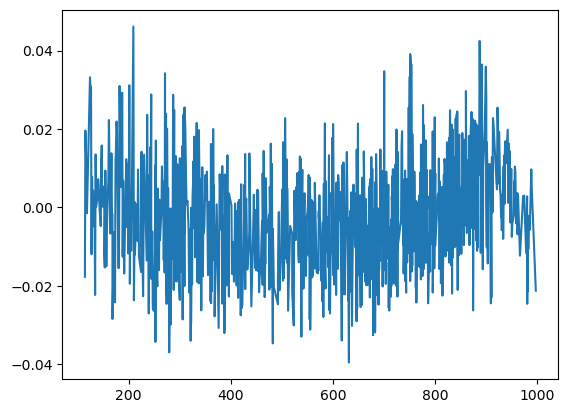

In [61]:
# mz = [m.replace('mz.', '') for m in mz]
# mz = [float(i) for i in mz]
plt.plot(mz,Data_train_r.mean())
plt.show()

In [62]:
cluster=pd.DataFrame(index=range(0,len(mz)),columns = ['m.z','NI'])
cluster.iloc[:,0]=mz
cluster.iloc[:,1]=Data_train_r.mean()

cluster.to_csv (r'E:/CRUK/ICR/Paolo_Upload_Apr2024/Data/cluster8.csv', index = False, header=True)

# *Randomly re-sample positive/negative to balance classes

In [7]:
from sklearn.utils.random import sample_without_replacement as resample

positives = (file['Label'] == 'Positive')
positives = file[positives]
negatives = (file['Label'] == 'Negative')
negatives = file[negatives]

# sample_50pos = resample (n_population=(len(positives)),n_samples=50)
# sample_50pos = positives
sample_50neg = resample (n_population=(len(negatives)),n_samples=68)

data_pos = positives
data_neg = negatives.iloc[sample_50neg,:]

frames=[data_pos, data_neg]
file_resample= pd.concat(frames)
Data_resample = file_resample.iloc[:,2:209]
# Data_resample = pd.concat(frames)
label = file_resample['Label'].tolist()

Data_resample

# Data pre-processing (i.e. extract common m/z & normalisation/scaling)

In [4]:
#define m/z axis

mz_trans=mz.transpose()
# mz_trans
mz_trans=np.reshape(mz_trans,(-1,1))
mz_trans.shape

(1025, 1)

In [5]:
# Normalisation/scaling
# options = median log transform(default), TIC normalisation, 
# SNV normalisation(don't usually use), MINMAX normalisation (don't usually use)
# you can of course 'stack' multiple normalisations, example given below TIC+median log

Data_n = data_norm(Data_train, method='tic')
# Data_n_s = data_norm(Data_train_s, method='tic')
Data_log = data_norm(Data_n, method='log')
# Data_log_s = data_norm(Data_n_s, method='log')
Data_log.shape

(67, 1025)

# Data visualisation

In [12]:
# sparse PCA
# use for cases when number of samples(e.g. patient) n << number of features(m/z) m

from sklearn.decomposition import SparsePCA
spca=SparsePCA(n_components=3,random_state=0)
sX_2D = spca.fit(Data_log).transform(Data_log)
sloadings = pd.DataFrame(spca.components_.T, columns=['PC1', 'PC2','PC3'])
sPCA_data=tmp_train
sPCA_data['PC1'] = sX_2D[:,0]
sPCA_data['PC2'] = sX_2D[:,1]
sPCA_data['PC3'] = sX_2D[:,2]
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
group_label = list(sPCA_data.columns)
sns.lmplot("PC1", "PC2", hue=group_label[2], data=sPCA_data, palette=colors, fit_reg=False)

C:\Users\yx2011\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


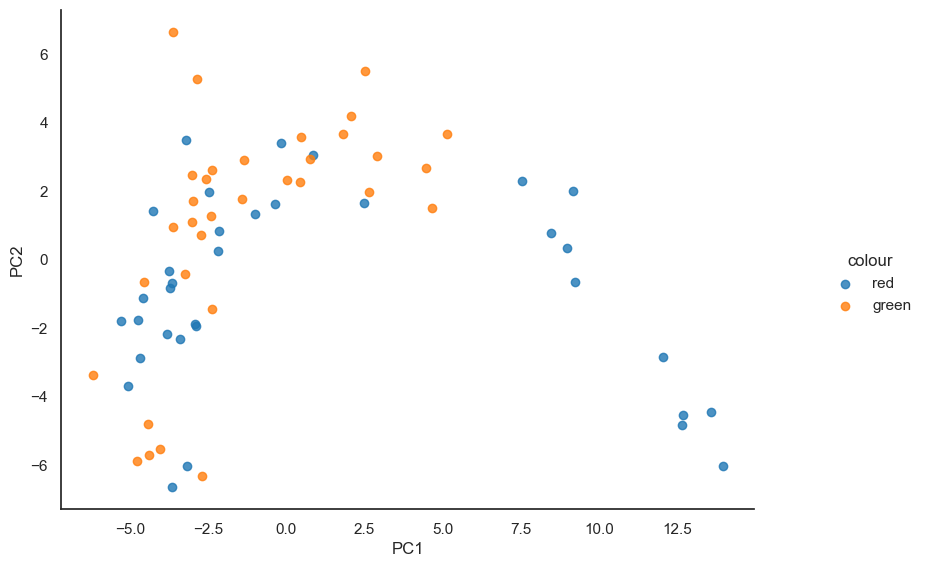

In [8]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=5) #keep first 5 components
X_2D = pca.fit(Data_log).transform(Data_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
# lw = 1

# PCA_data=tmp_train_r.copy()
PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


# sns.lmplot(x = "PC1", y = "PC2", hue='Cell line', data=PCA_data, palette=colors,fit_reg=False)
sns.lmplot(x = "PC1", y = "PC2", hue='colour', data=PCA_data, fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

#save it
# plt.savefig('D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/for Luca/PCA_pos.eps', format='eps')

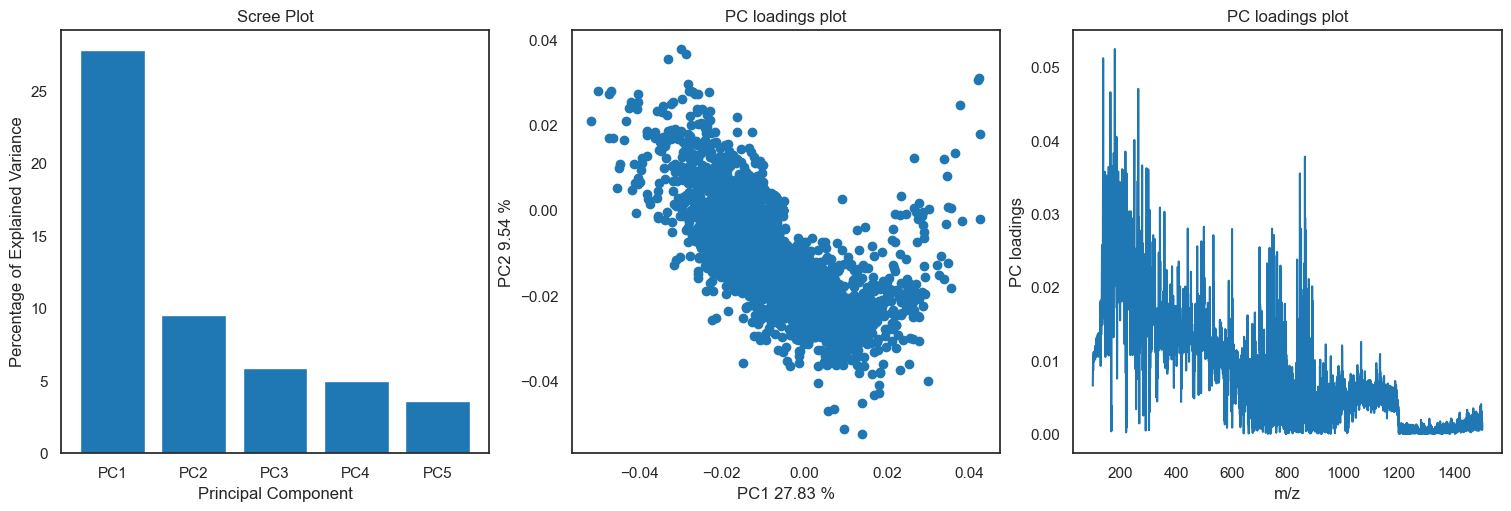

In [8]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC2'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');


## Batch effect correction

## COMBAT (https://academic.oup.com/biostatistics/article/8/1/118/252073?login=true)

In [6]:
from combat.pycombat import pycombat

Data_in = pd.DataFrame(data=Data_log)
Data_train_T = Data_in.T

batch = tmp_train['Batch'].values
corrected = pycombat(Data_train_T,batch)

corrected = corrected.T
corrected

Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


,0,1,2,3,4,5,6,7,8,9,...,2554,2555,2556,2557,2558,2559,2560,2561,2562,2563
0,-10.504252,-10.487156,-10.478962,-10.455741,-10.435702,-10.442349,-10.431802,-10.200599,-10.213264,-10.255244,...,-9.873055,-10.018119,-10.165534,-9.816281,-10.079712,-10.161851,-10.157142,-9.870406,-10.513659,-10.522093
1,-10.504252,-10.487156,-10.478962,-10.455741,-10.435702,-10.442349,-10.431802,-10.200599,-10.213264,-10.255244,...,-9.873055,-10.018119,-10.165534,-9.816281,-10.079712,-10.161851,-10.157142,-9.870406,-10.513659,-10.522093
2,-10.504252,-10.487156,-10.478962,-10.455741,-10.435702,-10.442349,-10.431802,-10.200599,-10.213264,-10.255244,...,-9.873055,-10.018119,-10.165534,-9.816281,-10.079712,-10.161851,-10.157142,-9.870406,-10.513659,-10.522093
3,-10.504252,-10.487156,-10.478962,-10.455741,-10.435702,-10.442349,-10.431802,-10.448610,-10.456557,-10.460829,...,-10.495090,-10.121948,-10.496820,-10.366268,-10.496511,-10.480866,-10.526376,-10.532153,-10.513659,-10.522093
4,-10.504252,-10.487156,-10.478962,-10.455741,-10.435702,-10.442349,-10.431802,-10.448610,-10.456557,-10.460829,...,-10.495090,-10.121948,-10.496820,-10.366268,-10.496511,-10.480866,-10.526376,-10.532153,-10.513659,-10.522093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,-10.445753,-10.207594,-10.106704,-10.036752,-9.842503,-9.967907,-10.005319,-10.044799,-10.287914,-10.258546,...,-10.141631,-9.286475,-9.949964,-9.499232,-9.839639,-9.748542,-10.034645,-10.216998,-10.233770,-10.392071
393,-10.445753,-10.473208,-9.818261,-9.721150,-9.717133,-9.801671,-9.848757,-9.858192,-9.808334,-9.732413,...,-9.964290,-9.565310,-10.362608,-9.370838,-9.565049,-10.062340,-9.816085,-9.650930,-10.428940,-10.392071
394,-10.445753,-10.473208,-9.818261,-9.721150,-9.717133,-9.801671,-9.848757,-9.858192,-9.808334,-9.732413,...,-9.964290,-9.565310,-10.362608,-9.370838,-9.565049,-10.062340,-9.816085,-9.650930,-10.428940,-10.392071
395,-10.445753,-10.473208,-9.818261,-9.721150,-9.717133,-9.801671,-9.848757,-9.858192,-9.808334,-9.732413,...,-9.964290,-9.565310,-10.362608,-9.370838,-9.565049,-10.062340,-9.816085,-9.650930,-10.428940,-10.392071


C:\Users\yx2011\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


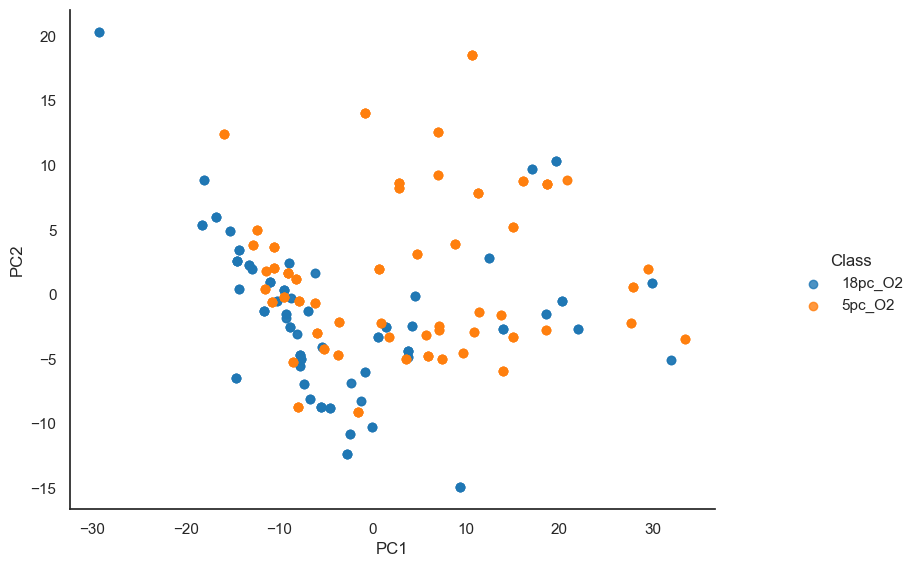

In [7]:
# check batch correction result

pca = PCA(n_components=5) #keep first 3 components
X_2D = pca.fit(corrected).transform(corrected)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3','PC4','PC5'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
# lw = 1

# PCA_data=tmp_train_r.copy()
PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]
PCA_data['PC4'] = X_2D[:,3]
PCA_data['PC5'] = X_2D[:,4]


# sns.lmplot(x = "PC1", y = "PC2", hue='Cell line', data=PCA_data, palette=colors,fit_reg=False)
sns.lmplot(x = "PC1", y = "PC2", hue='Class', data=PCA_data, fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

## 3D PCA (need to install plotly for this to work!)

In [38]:
import plotly.express as px

fig = px.scatter_3d(PCA_data, x='PC1', y='PC2', z='PC3',
              color='Class')
fig.update_traces(marker_size = 5)
fig.show()
#ax.scatter3D(xdata, ydata, zdata, c=file['Label'], label=file['Label']);
#fig = plt.gcf()
#fig.set_size_inches(12,6)

# Non-linear data visualisation

## t-SNE (select n_components depending on whether you want 2D or 3D plots)

In [7]:
%%time
from sklearn.manifold import TSNE

X_embedded = TSNE(n_components=3, init='pca',perplexity = 5,
                  learning_rate = 50).fit_transform(Data_log)
# X.dtype

CPU times: total: 3.75 s
Wall time: 1.15 s


### 2D plot

In [8]:
import plotly.express as px
fig = px.scatter(x=X_embedded[:,0], y=X_embedded[:,1], color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan"])
# fig.set_size_inches(10,6)
fig.update_layout(
        xaxis_title='t-SNE dimension 1',
        yaxis_title='t-SNE dimension 2',
    )
fig.show()

In [9]:
import plotly.express as px
fig = px.scatter_3d(x=X_embedded[:,0], y=X_embedded[:,1], z=X_embedded[:,2],
              color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan"])
fig.update_traces(marker_size = 8)
fig.update_layout(autosize=False,
        width=1000,
        height=800,
    scene = dict(
#         zaxis = dict(range=[-80,80]),
#     yaxis = dict(range=[-80,80]),
        xaxis_title='t-SNE dimension 1',
        yaxis_title='t-SNE dimension 2',
        zaxis_title='t-SNE dimension 3',
    ),
)
# fig.show()

## UMAP (set n_components similarly)

In [31]:
# Dimension reduction and clustering libraries
import umap.umap_ as umap
# import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.preprocessing import label_binarize

In [118]:
%%time
# target = label_binarize(tmp_train['Label'], classes=['AD', 'CTRL'])
clusterable_embedding = umap.UMAP(init = 'pca',
    n_neighbors=60,
    min_dist=0.3,
    spread = 0.4, 
    n_components=2
).fit_transform(Data_log)

CPU times: total: 6.95 s
Wall time: 3.76 s


In [119]:
import plotly.express as px
fig = px.scatter(x=clusterable_embedding[:,0], y=clusterable_embedding[:,1], color=tmp_train['Class'],color_discrete_sequence=["magenta", "cyan",'green','red','blue'])
# fig.set_size_inches(10,6)
fig.update_layout(
        xaxis_title='UMAP dimension 1',
        yaxis_title='UMAP dimension 2',
    )
fig.show()

In [ ]:
##### import plotly.express as px
fig = px.scatter_3d(x=clusterable_embedding[:,0], y=clusterable_embedding[:,1], z=clusterable_embedding[:,2],
              color=tmp_train['Class'],color_discrete_sequence = ['red','green','pink','navy','black'])
fig.update_traces(marker_size = 6)
fig.update_layout(autosize=False,
        width=1000,
        height=800,
    scene = dict(
#         xaxis = dict(range=[-10,10]),
#         yaxis = dict(range=[-10,10]),
#         zaxis = dict(range=[-5,8]),
        xaxis_title='UMAP dimension 1',
        yaxis_title='UMAP dimension 2',
        zaxis_title='UMAP dimension 3',
    ),
)

## *Feature selection using PCA (only if you have clear linear separation within a component)

In [71]:
# PC=loadings['PC3']
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project B/mz.txt', mz,delimiter=',')
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project b/pc.txt', PC,delimiter=',') #for me to save the components

# sorted_loading_values = PC.abs().sort_values(ascending=False)
# # sorted_loading_values
# top_30_mz = sorted_loading_values[0:100].index
# top_30_mz
# PCA_features=mz[top_30_mz]
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_PCA_APCvsKRAS.txt', PCA_features,delimiter=',')

# Classification models

In [30]:
# get group sizes to be used for cost sensitivity if biased
column = tmp_train_r['cluster']

labelnames = set(column)
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train_r[column== labelnames[i]]
#     group=file_resample[column== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

print('ratio: '+str(w/max(w)))
weights = {labelnames[0]:1.0, labelnames[1]:w[0]/w[1]}

labelnames

group0 sampe size: 9631.0

group1 sampe size: 4711.0

group2 sampe size: 472.0

group3 sampe size: 5790.0

group4 sampe size: 803.0

group5 sampe size: 3561.0

group6 sampe size: 3032.0

ratio: [1.         0.48914962 0.04900841 0.60118368 0.0833766  0.36974354
 0.31481674]


[1, 2, 3, 4, 5, 6, 7]

## Train models with CV
## you can select the classifier ('method'), the cross-validation strategy ('cvsplit', ATM only LOGO or stratified K-fold) and implement a cost-sensitive approach (input 'weights')

## method available = 'LR'(Logistic Regression), 'LDA'(Liner Discriminant Analysis), 'KNN'(k-Nearest Neighbours), 'CART'(Decision Trees), 'NB'(Naiive Bayesian), 'SVM'(Support Vector Machine), 'RF'(Random Forest)

## CV strategies available = 'loo' (leave-one-group-out as specified by 'group' argument), 'kfold' (stratified, default k=10)

In [10]:
[results,model] = train_cv (Data_log, method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=tmp_train['Tissue'], weights = weights)

Method SVC(class_weight={'Normal': 1.0, 'Trisomic': 0.978681063188383},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 181195.86070775986 seconds


## *Visualise CV splitting behaviour (for k-fold mostly)

C:\Users\yx2011\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:725: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=10.



<Axes: title={'center': 'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

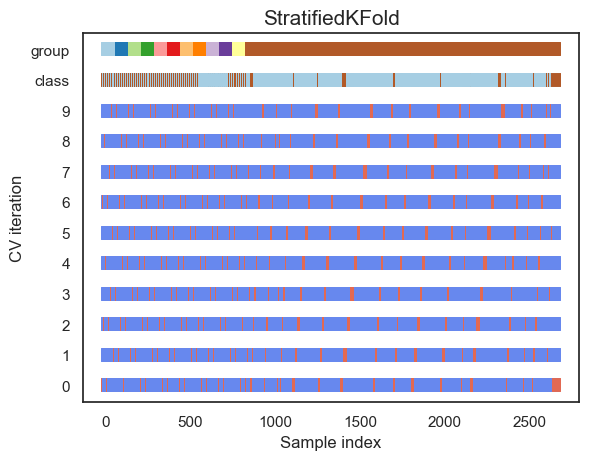

In [46]:
sns.set_context("notebook")
cvsplit = StratifiedKFold(n_splits=10)
old_label = tmp_train['Class'].copy()
old_group = tmp_train['File'].copy()
plot_cv(cvsplit, Data_log, old_label, old_group, 10, lw=10)

## Model(s) evaluation - confusion matrix & ROC analysis

## if you want CM in sample numbers then just take away the 'normalize = true' during calculation

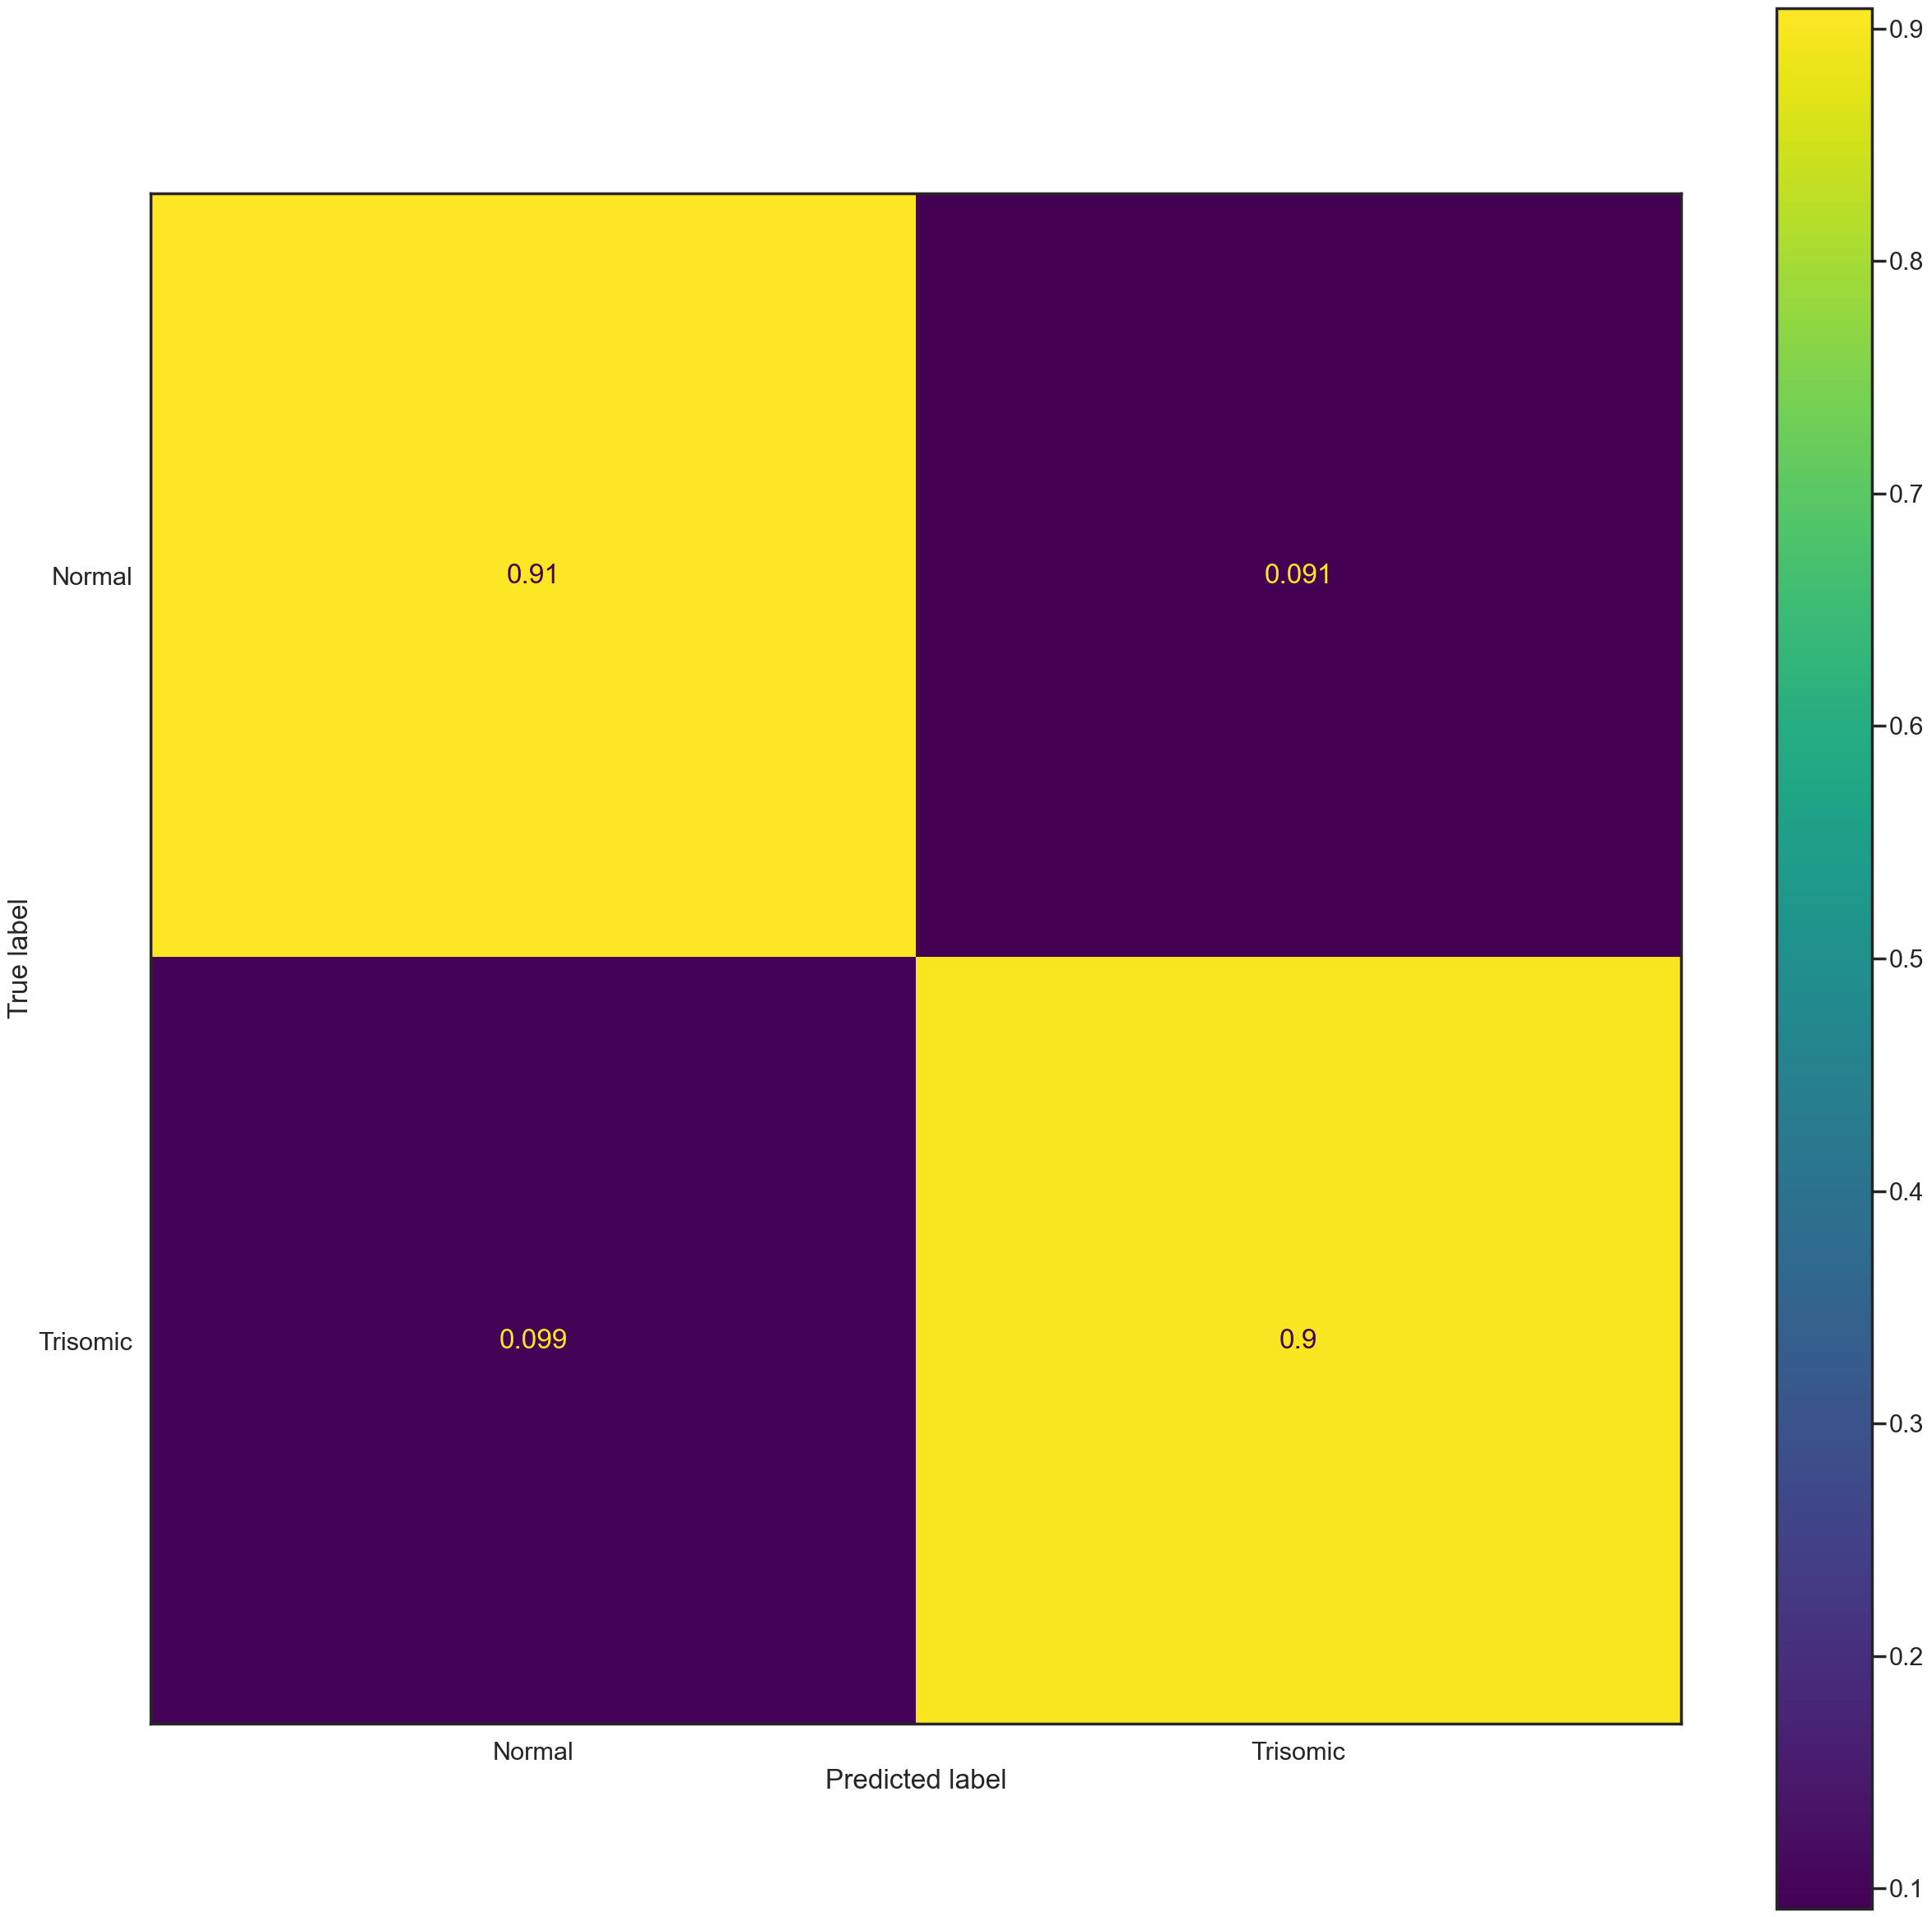

In [11]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_style("white")
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results,normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [12]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,Normal,0.905054,0.90884,0.901267,0.902009,0.905412
1,Trisomic,0.905054,0.901267,0.90884,0.908145,0.904693
2,Average,0.905054,0.905054,0.905054,0.905077,0.905052


## ROC analysis - this will plot the 'macro average' if you have more than 2 classes, you can plot for a particular class by e.g. defining the input argument 'plotwhich=2' (so plot ROC for class 2); and in the case of k-fold, it currently plots a randomly selected 'fold' (i.e. the performance may change everytime you plot); you can also save the predicted probabilities by defining 'saveprobs=True'
## to-do: plot the average of k-fold

LOGO
there are 2 classes


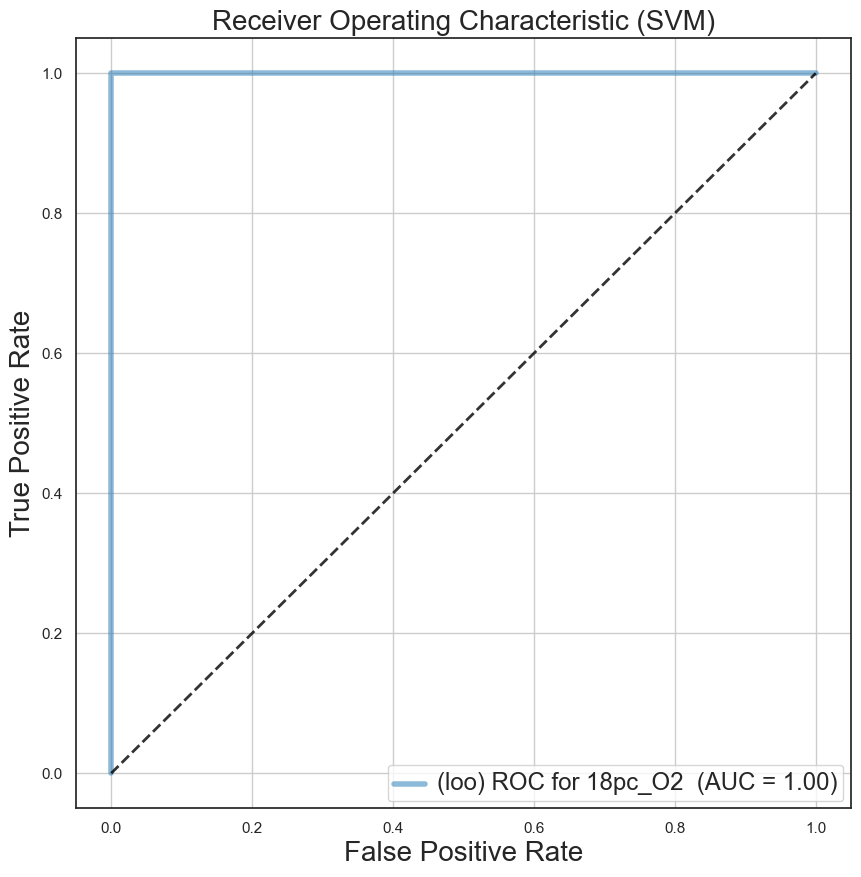

CPU times: total: 34.3 s
Wall time: 34.7 s


In [128]:
%%time
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from random import randrange

[model, all_probs, all_y, FPRs, TPRs, AUCs] = do_ROC (Data_log, tmp_train['Class'].values, 
                                               group = tmp_train['File'].values, method='SVM', 
                                        cvsplit='loo', plotwhich = 0, saveprobs = False)

## *customising ROC curve plots

In [52]:
all_probs_1=all_probs.copy() 
all_y_1 = all_y.copy() 
FPRs_1 = FPRs.copy() 
TPRs_1 = TPRs.copy() 
AUCs_1 = AUCs.copy()

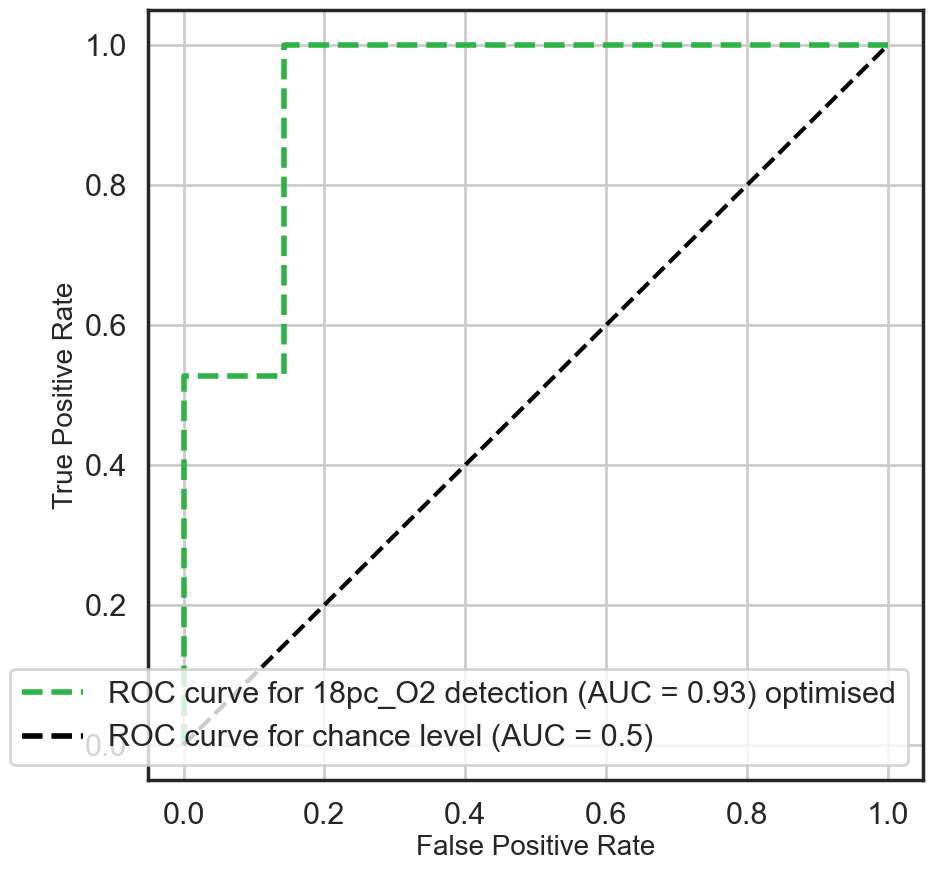

In [19]:
X = Data_log
Y = tmp_train['Class'].values
group = tmp_train['Class'].values
cv = StratifiedKFold(n_splits=10)
model = ((SVC(probability=True, kernel = 'linear',
                                      decision_function_shape='ovo',class_weight = weights)))

all_y = []
all_probs=[]
for train, test in cv.split(X, group):
    all_y.append(Y[test])
    all_probs.append(model.fit(X[train], Y[train]).predict_proba(X[test]))

TPRs = dict()
FPRs = dict()
AUCs = dict()
for n in range(len(all_y)):
    all_probs_n = all_probs[n]
    all_y_n = all_y[n]
    FPRs[n], TPRs[n], _ = roc_curve(all_y_n,all_probs_n[:,0],pos_label=cm_label[0])
    AUCs[n] = auc(FPRs[n], TPRs[n])

    
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([FPRs[i] for i in range(len(all_y))]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(all_y)):
    mean_tpr += np.interp(all_fpr, FPRs[i], TPRs[i])

mean_tpr /= len(all_y)
mean_tpr[0] = 0.0

FPRs["macro"] = all_fpr
TPRs["macro"] = mean_tpr
AUCs["macro"] = auc(FPRs["macro"], TPRs["macro"])

plt.figure(1, figsize=(10,10))
# plt.plot(
#     FPRs_1[0],
#     TPRs_1[0],
#     label='ROC curve for %s detection (AUC = %0.2f)' % (cm_label[0], AUCs_1[0]),
#     color="#df7d20",
#     linestyle="solid",
#     linewidth=4,
# )
plt.plot(
    FPRs[0],
    TPRs[0],
    label='ROC curve for %s detection (AUC = %0.2f) optimised' % (cm_label[0], AUCs[0]),
    color="#30b346",
    linestyle='dashed',
    linewidth=4,
)
# plt.plot(
#     FPRs['macro'],
#     TPRs['macro'],
#     label='ROC curve for %s detection (AUC = %0.2f) LR' % (cm_label[0], AUCs[0]),
#     color="#224fdf",
#     linestyle='dotted',
#     linewidth=4,
# )
plt.plot([0, 1], [0, 1], "k--", label="ROC curve for chance level (AUC = 0.5)")
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate',fontsize=20)
leg = plt.legend(loc="lower right")
leg_lines = leg.get_lines()
leg_texts = leg.get_texts()
plt.setp(leg_lines, linewidth=4)
# plt.setp(leg_texts, fontsize='x-large')
plt.grid()
# plt.savefig("ROCs.pdf", format="pdf", bbox_inches="tight")
plt.show()



In [17]:
TPRs[0]

array([0.        , 0.21052632, 0.31578947, 0.36842105, 0.52631579,
       0.52631579, 0.73684211, 0.84210526, 1.        , 1.        ,
       1.        , 1.        , 1.        ])

In [45]:
operation_ind = np.argmin(np.abs(TPRs['macro']-(1-FPRs['macro'])))
print('threshold sensitivity is %0.4f' % (TPRs['macro'][operation_ind]))
print()
print('threshold specificity is %0.4f' % (1-FPRs['macro'][operation_ind]))

threshold sensitivity is 0.0000

threshold specificity is 1.0000


# Save trained model & test new data

## the trained model will be saved to a folder called 'Trained_models', you can name the model to be anything (e.g. 'XXX.sav')

In [70]:
model = (SVC(probability=True, kernel = 'linear',
                                      decision_function_shape='ovo',class_weight = weights))
model_tosave = model
model_tosave.fit(Data_log, column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/trained_SVM_HyReS.sav', 'wb'))

SVC(class_weight={'Normal': 1.0, 'Trisomic': 0.978681063188383},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


In [83]:
# load test data from file

tmp_test, Data_test, mz_test = load_data("test_data_ratios.csv", lcdata=1,features = allfeatures)
Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test_n, method='log')
Data_test_log.shape

test data truncated to include only selected spectral features within (100.00) ppm


(245, 89)

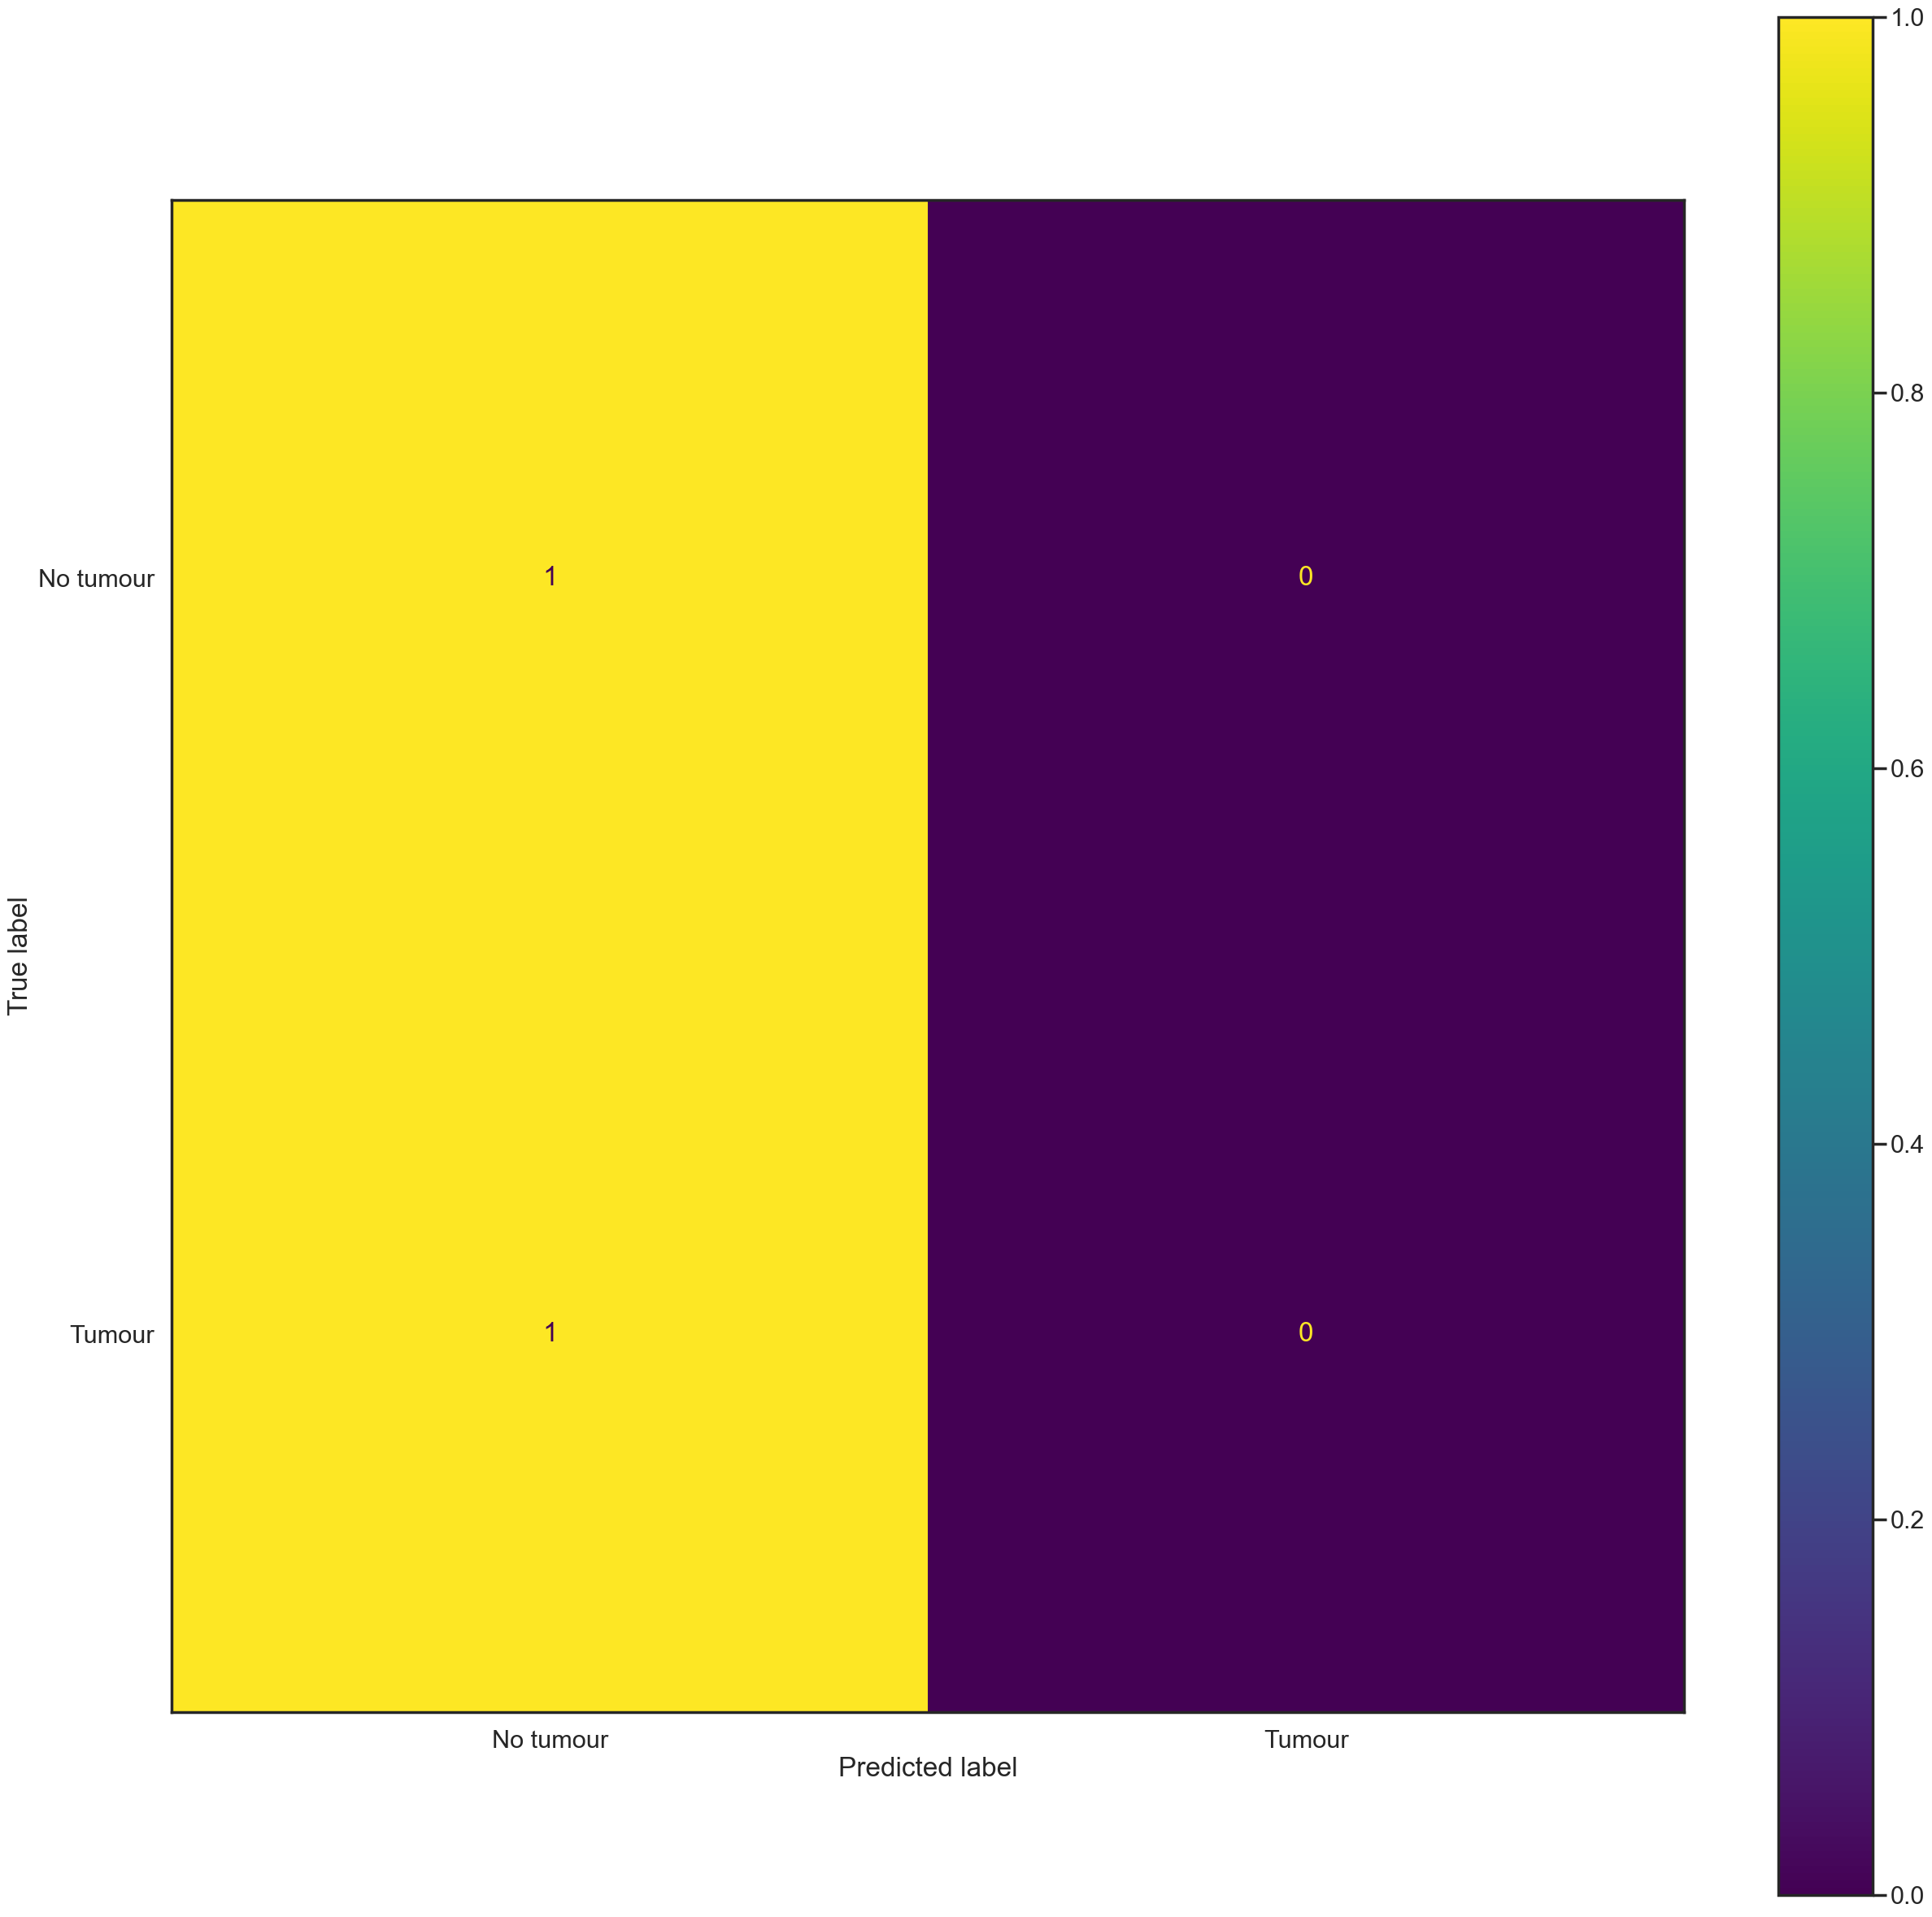

In [84]:
model_name = 'Trained_models/SVM_test2.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['binary_path'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

## the CM alone can be 'deceiving' as most trained models are probabilistic and give the probabilities of a sample belonging to a certain class. If an inappropriate threshold was chosen (i.e. P>=threshold to be predicted to be a certain class), then the performance may appear to worsen when compared to CV results. To understand where this threshold should be, also check the ROC curves for the test data

In [42]:
[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_test_log, tmp_test['binary_path'].values, saved_model = loaded_model,
        plotwhich = 'macro', saveprobs = True)

there are 2 classes


UnboundLocalError: cannot access local variable 'all_y_n' where it is not associated with a value

# Feature selection methods

## Feature selection with LR - there are 3 main methods:

## 1. Using the relative importance of LR coefficients obtained during model training; if you have more than 2 classes, then remember that LR CANNOT do true multi-class classification and instead it will do 'one-vs-rest' for as many times as you have classes. The output features are automatically saved (unless you turn it off with 'save = False') and you can define the number features (e.g. num_features = 50)

In [129]:
LR_features, importance = LR_importance(Data_log, tmp_train['Class'], num_features = 50, save=True)
print(LR_features)

             0
0   253.138001
1   254.140884
2   871.667603
3   871.510620
4   761.544434
5   335.131653
6   253.212814
7   120.672691
8   875.698486
9   254.215851
10  763.576904
11  335.213989
12  315.181519
13  240.509109
14  288.161041
15  597.294190
16  888.547791
17  861.526001
18  859.558716
19  307.257446
20  242.116180
21  689.543213
22  885.947327
23  834.507873
24  312.074890
25  710.640686
26  686.598877
27  212.833878
28  684.585938
29  155.242706
30  885.527466
31  599.299622
32  282.246460
33  687.536743
34  281.244385
35  478.279816
36  873.527771
37  887.542481
38  293.863495
39  762.283691
40  174.814606
41  911.549316
42  730.546631
43  563.493408
44  165.165817
45  886.531616
46  436.271240
47  200.357590
48  240.978607
49  242.001663


## *Feature selection for LR using log-likelihood test, only for binary classification!

In [39]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

LR_features2 = LR_loglike(Data_log, tmp_train_r['Label'], threshold = 2.0, save = False)
LR_features2

array([  50.16054535,   52.30213547,   61.0007515 , ..., 1498.84692383,
       1499.19555664, 1500.20202637])

## Feature selection using RFE (Recursive Feature Elimination)
## standard RFE produces any defined number of features

In [117]:
# Here I chose 30 features

from sklearn.feature_selection import RFE
print(model)

RFE_features = RFE_select(Data_log, tmp_train['GD2 level'],n_features = 100)
RFE_features

SVC(class_weight={'low': 0.75, 'negative': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 3091.9161829948425 seconds


,0
0,146.980804
1,173.886902
2,174.029892
3,179.054596
4,187.129837
...,...
95,1404.042603
96,1404.809082
97,1455.775146
98,1464.857544


## if you are unsure how many features are necessary, use RFECV below as it will use a CV-based 'grid search' to also determine the optimal numer of features (5-fold by default), this is much slower!

In [43]:
# RFECV - use CV to determine & select best number of features

from sklearn.feature_selection import RFECV
print(model)

RFECV_features = RFECV_select(Data_log, tmp_train['binary_path'])
RFECV_features

SVC(class_weight={'No tumour': 0.434971098265896, 'Tumour': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)

that took 3188.0299365520477 seconds


,0
0,192.9953/574.4977
1,192.9953/692.5098
2,192.9953/745.5607
3,192.9953/770.585
4,306.2655/626.5484
...,...
84,794.5787/846.6758
85,794.5787/891.7357
86,846.6758/892.7387
87,891.7357/917.7499


## Feature selection with LASSO (only for binary classification!)

In [189]:
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

lasso_features = LASSO_select(Data_log,tmp_train['Label'])
lasso_features

D:\anaconda3\lib\site-packages\sklearn\utils\validation.py:73: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



the LASSO classification accuracy was 0.0


,0


## Combine different FS approaches to generate a list of (overlapping) features & generate new data matrix with only these features

In [65]:
allfeatures = match_features([RFECV_features])
allfeatures

Data_train_s=np.zeros((len(Data_train),len(allfeatures)))
for n in range (0,len(allfeatures)):
    try:
        index = np.argmin(abs(mz-allfeatures[n]))
    except:
        dum = np.where(mz == allfeatures[n])
        index = int(dum[0])
    Data_train_s[:,n]=Data_train.iloc[:,index]
    
output = pd.DataFrame(data=Data_train_s)
output['binary_path'] = tmp_train['binary_path']
# output['cell number'] = tmp_train['cell number']
i = 0
for mz_i in allfeatures:
#     print(mz_i)
    try:
        mz_i = float(mz_i)
    except:
        mz_i = str(mz_i)
    output = output.rename(columns={i: (mz_i)})
    i = i+1
output

,['192.9953/574.4977'],['192.9953/692.5098'],['192.9953/745.5607'],['192.9953/770.585'],['306.2655/626.5484'],['306.2655/703.5237'],['306.2655/704.5233'],['572.4922/575.4993'],['572.4922/661.4947'],['572.4922/678.5552'],...,['772.5984/921.78'],['775.5607/794.5787'],['775.5607/891.7357'],['789.5364/891.7357'],['794.5787/846.6758'],['794.5787/891.7357'],['846.6758/892.7387'],['891.7357/917.7499'],['917.7499/921.78'],binary_path
0,12.880658,2.775030,4.119868,2.661087,4.253726,0.814737,2.857866,0.085796,0.856322,6.476487,...,0.254573,0.083367,0.454589,4.224703,0.310555,0.058884,0.229131,1.459571,0.812910,Tumour
1,15.947145,2.738185,4.380138,1.950070,5.469820,1.193463,3.963765,0.170317,0.820581,7.341011,...,1.177073,0.053298,0.230539,1.792153,0.228213,0.053929,0.108816,0.783227,1.141479,No tumour
2,7.521731,2.131989,0.999201,1.502155,3.310439,0.949412,2.002370,0.043135,0.217211,3.187576,...,0.906252,0.062753,0.129626,0.293519,0.293946,0.051608,0.068720,0.693941,0.854751,No tumour
3,6.782932,2.011494,2.780797,3.174370,2.459962,0.751848,1.918610,0.138554,1.783953,4.691187,...,0.345763,0.069216,0.376215,0.482638,0.336478,0.048915,0.106574,0.482872,1.099043,Tumour
4,9.527890,2.859484,2.384739,0.386889,2.816159,0.925259,2.374781,0.123824,0.150301,0.843002,...,3.990103,0.191810,1.073518,2.923031,1.555604,0.405037,0.511851,1.680078,1.407329,Tumour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,31.055860,0.367368,2.355238,0.043096,1.484573,1.153527,3.271488,0.895341,0.102722,2.963591,...,0.591692,0.439819,2.868855,0.072477,0.225454,0.581612,0.408889,0.874327,0.401558,No tumour
989,22.452704,0.146784,1.760245,0.047799,1.661288,1.262818,3.234907,0.877544,0.106318,1.304893,...,0.225364,0.224219,0.707887,0.161761,0.312787,0.848921,1.211497,2.666049,4.652257,No tumour
990,6.094062,1.469684,2.718616,0.311380,1.412090,1.350266,4.133493,0.605212,0.228716,1.273048,...,1.156171,0.396294,1.197782,0.175015,0.473395,0.648808,0.432919,1.751017,0.004109,No tumour
991,8.276000,1.342959,1.195871,0.128610,3.697714,1.573035,4.685126,0.480876,0.120828,1.355028,...,0.263500,0.317675,1.515141,0.130998,0.920722,0.848930,0.802553,0.330299,0.053067,No tumour


## Save new data matrix

In [16]:
output.to_csv (r'data_select_filt.csv', index = False, header=True)
output

,115.918418884277,139.109771728516,141.089218139648,141.220367431641,142.020812988281,163.111450195312,167.03564453125,169.121566772461,172.944869995117,173.006713867188,...,783.008239746094,866.025939941406,881.569396972656,882.553039550781,882.935729980469,883.561584472656,886.578369140625,1053.6328125,colour,cell number
0,98.000000,116.000000,1160.000000,0.000000,617.000000,174.000000,415.000000,767.000000,17.000000,137.000000,...,701.000000,127.000000,116.000000,72.000000,32.000000,120.000000,60.000000,51.000000,red,1
1,232.000000,3257.336736,7396.040213,5779.712596,357.532677,651.925196,212.529157,530.000000,452.192961,121.814349,...,583.515916,121.000000,93.476403,32.742901,53.404477,142.069284,91.773161,39.830371,red,2
2,146.688565,2156.689756,1576.631061,186.427717,285.784776,286.648341,271.494415,456.000000,345.594543,128.826170,...,212.869524,34.194728,50.964798,35.390076,35.654427,36.086749,38.170655,88.005301,red,3
3,140.000000,2097.889695,193.000000,213.184340,335.298479,30.003911,378.236446,564.000000,292.289662,82.208087,...,123.979616,62.214003,263.734893,250.441926,245.270239,236.812427,196.043533,7.898281,green,4
4,176.706694,121.000000,541.000000,473.393226,60.767731,383.777548,229.682930,372.000000,208.715748,26.000000,...,109.925813,53.000000,53.052326,61.415862,64.669733,69.991134,74.588712,78.946294,green,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,139.000000,219.241504,746.346970,771.504829,158.915963,355.800945,156.798428,360.674507,333.471361,186.734960,...,43.475727,127.236060,121.012160,120.618291,120.465054,120.214450,119.006471,0.000000,green,68
63,163.448635,301.016100,722.679419,743.390269,146.733493,358.526798,353.000000,400.621261,205.082071,64.149169,...,17.608647,60.001518,63.530766,63.754108,63.841001,63.983105,64.668087,86.053210,green,69
64,146.000000,120.000000,787.805081,1370.452014,6241.508678,425.009177,184.844616,407.313958,299.620754,156.733332,...,15.705188,12.424125,11.809810,11.770934,11.755809,11.731073,11.611843,5.009442,green,70
65,153.204208,110.222720,705.059691,768.666748,148.996042,88.195016,98.000000,432.959184,519.922971,409.376508,...,92.320392,141.569954,150.790980,151.374518,151.601546,151.972829,153.762512,252.866173,green,71


## Train & evaluate new model with only selected features

In [68]:
results = train_cv (Data_log_s, method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=tmp_train['binary_path'], weights = weights)

Method SVC(class_weight={'No tumour': 0.434971098265896, 'Tumour': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 1.9426274299621582 seconds


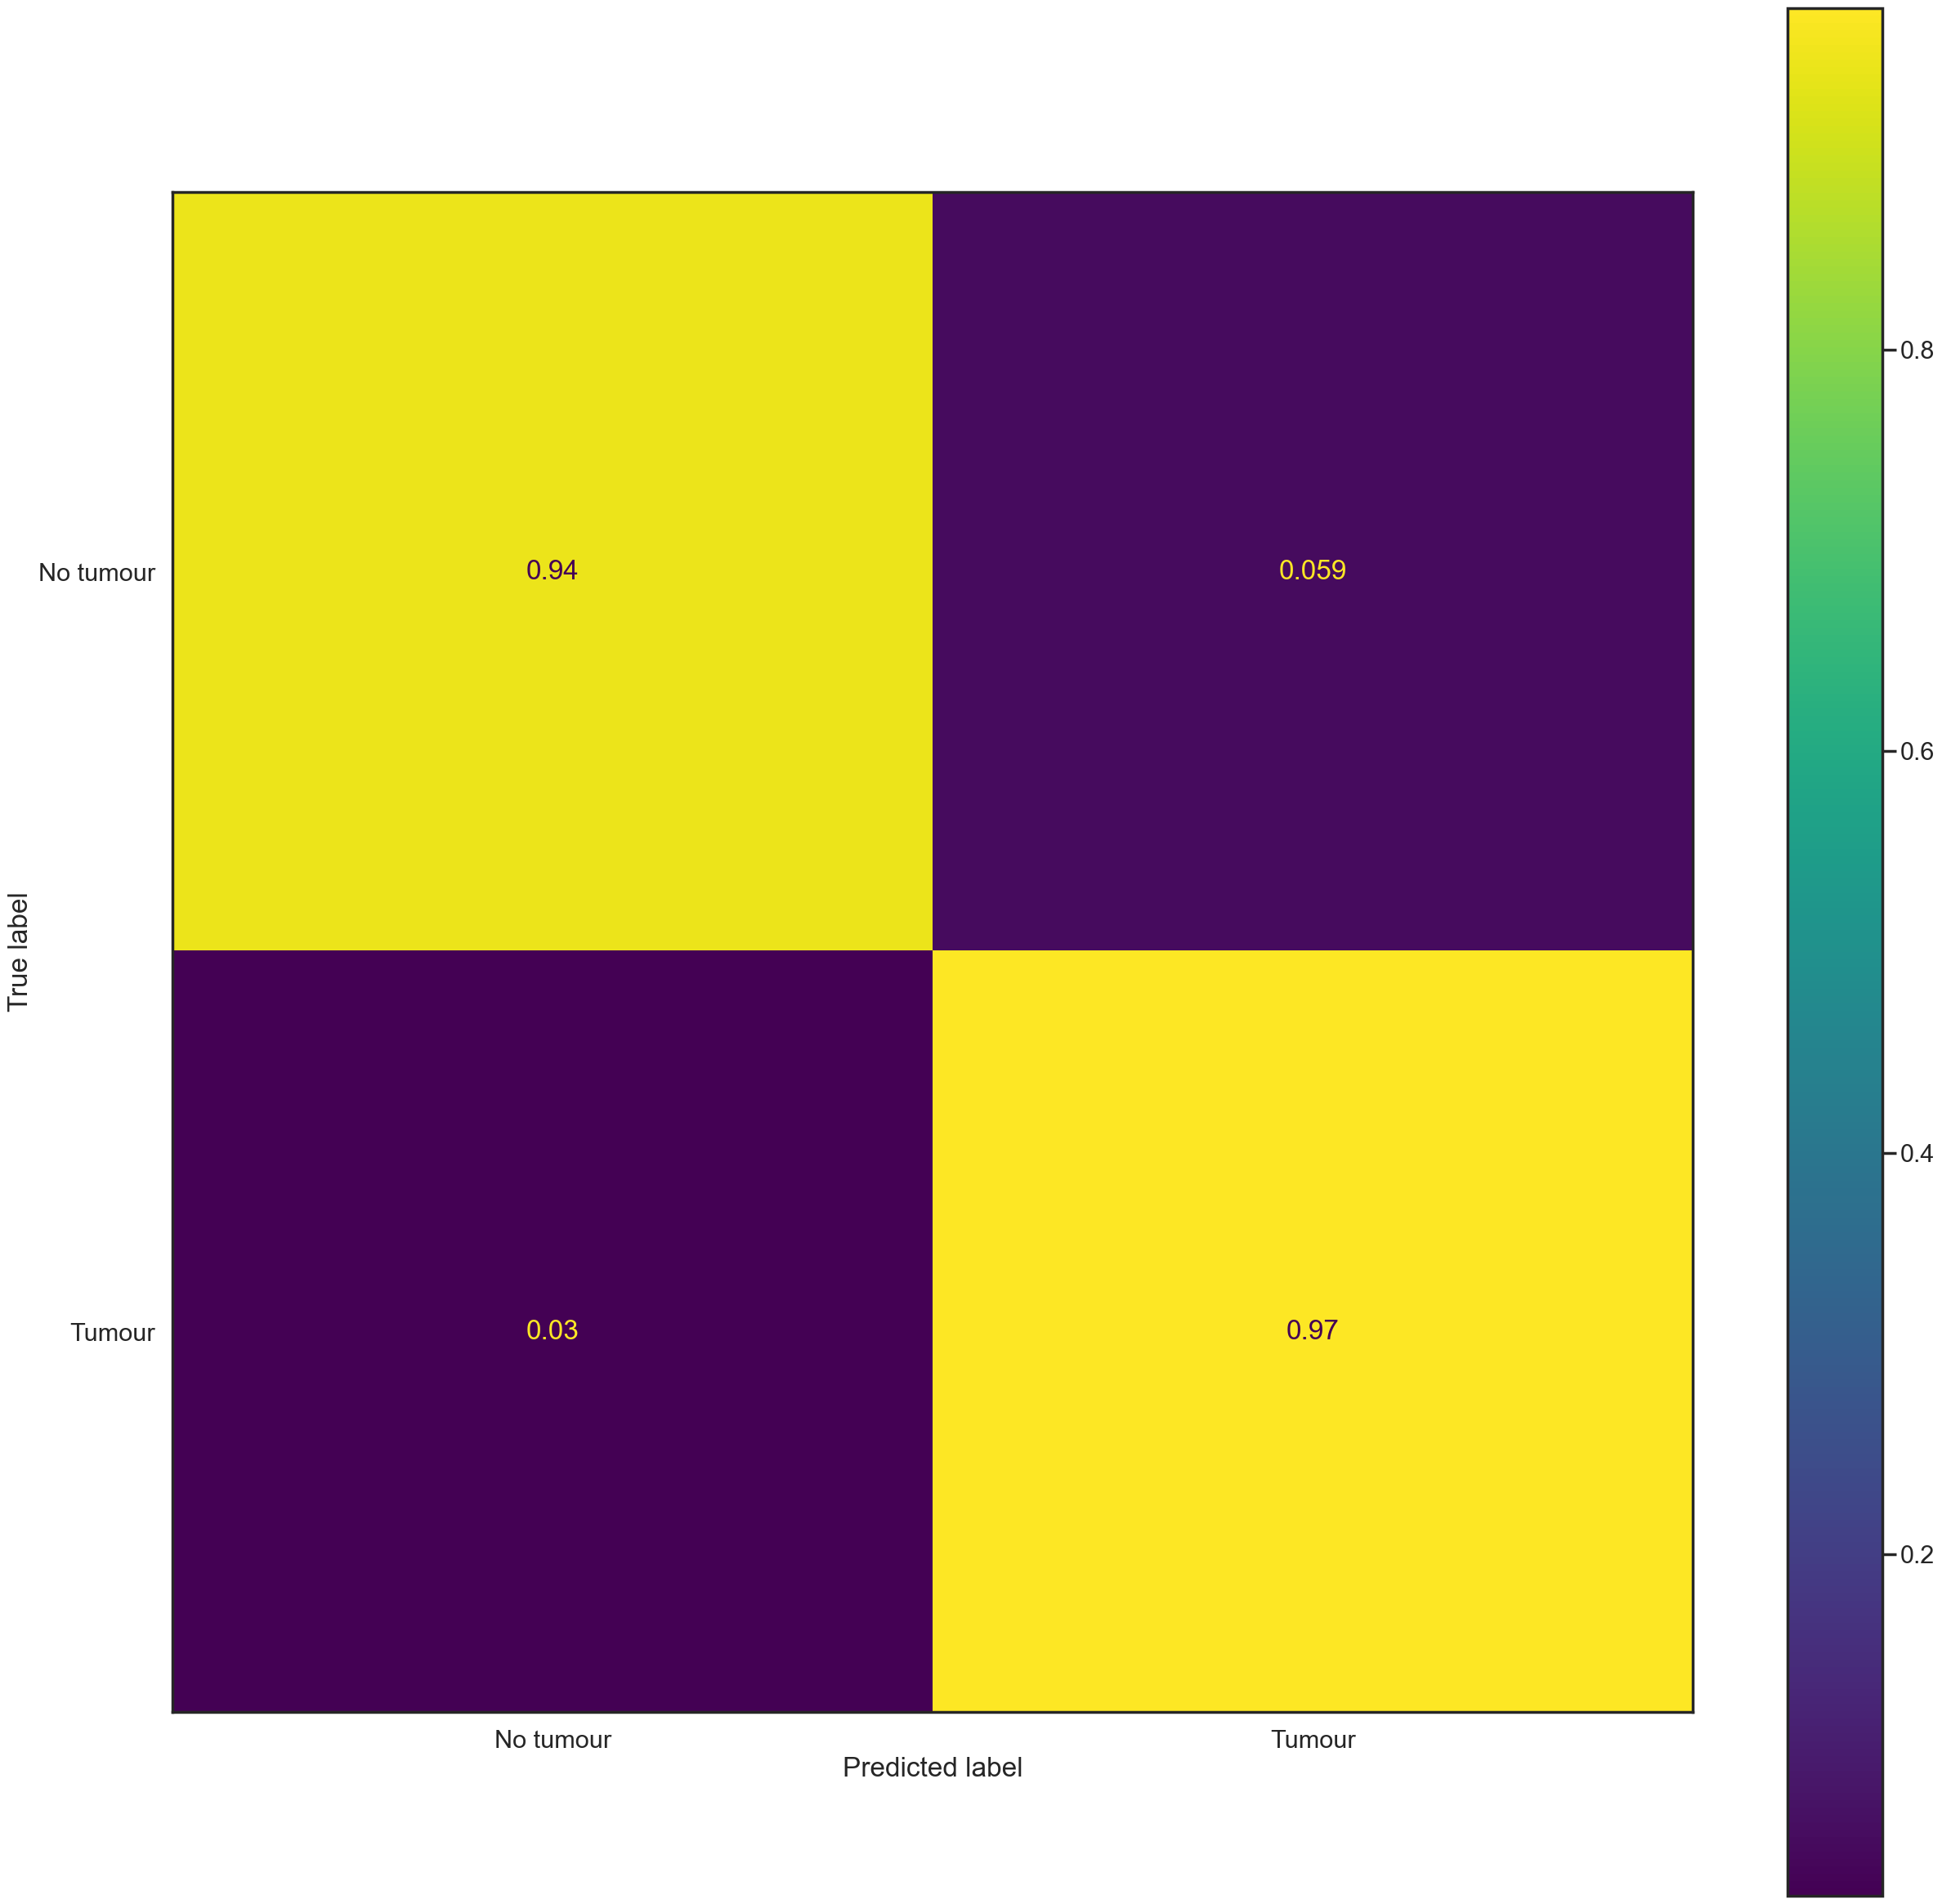

In [69]:
sns.set_context("poster")

classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [70]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,No tumour,0.955426,0.940751,0.9701,0.969196,0.954762
1,Tumour,0.955426,0.9701,0.940751,0.942441,0.95607
2,Average,0.955426,0.955426,0.955426,0.955818,0.955416


In [71]:
[model, all_probs, all_y, FPRs, TPRs, AUCs] = do_ROC (Data_log_s, tmp_train['binary_path'], 
                                               group = tmp_train['binary_path'], method='SVM', 
                                        cvsplit='kfold', plotwhich = 0, saveprobs = True)

kfold


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

## Save new model with only selected features

In [72]:
model_tosave = model
model_tosave.fit(Data_log_s, column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_test2.sav', 'wb'))

SVC(class_weight={'No tumour': 0.434971098265896, 'Tumour': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


## Load data and test with new model

In [223]:
tmp_test, Data_test,mz_test = load_data("OPO_data.csv", features = allfeatures)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

test data truncated to include only selected spectral features within (100.00) ppm


(502, 204)

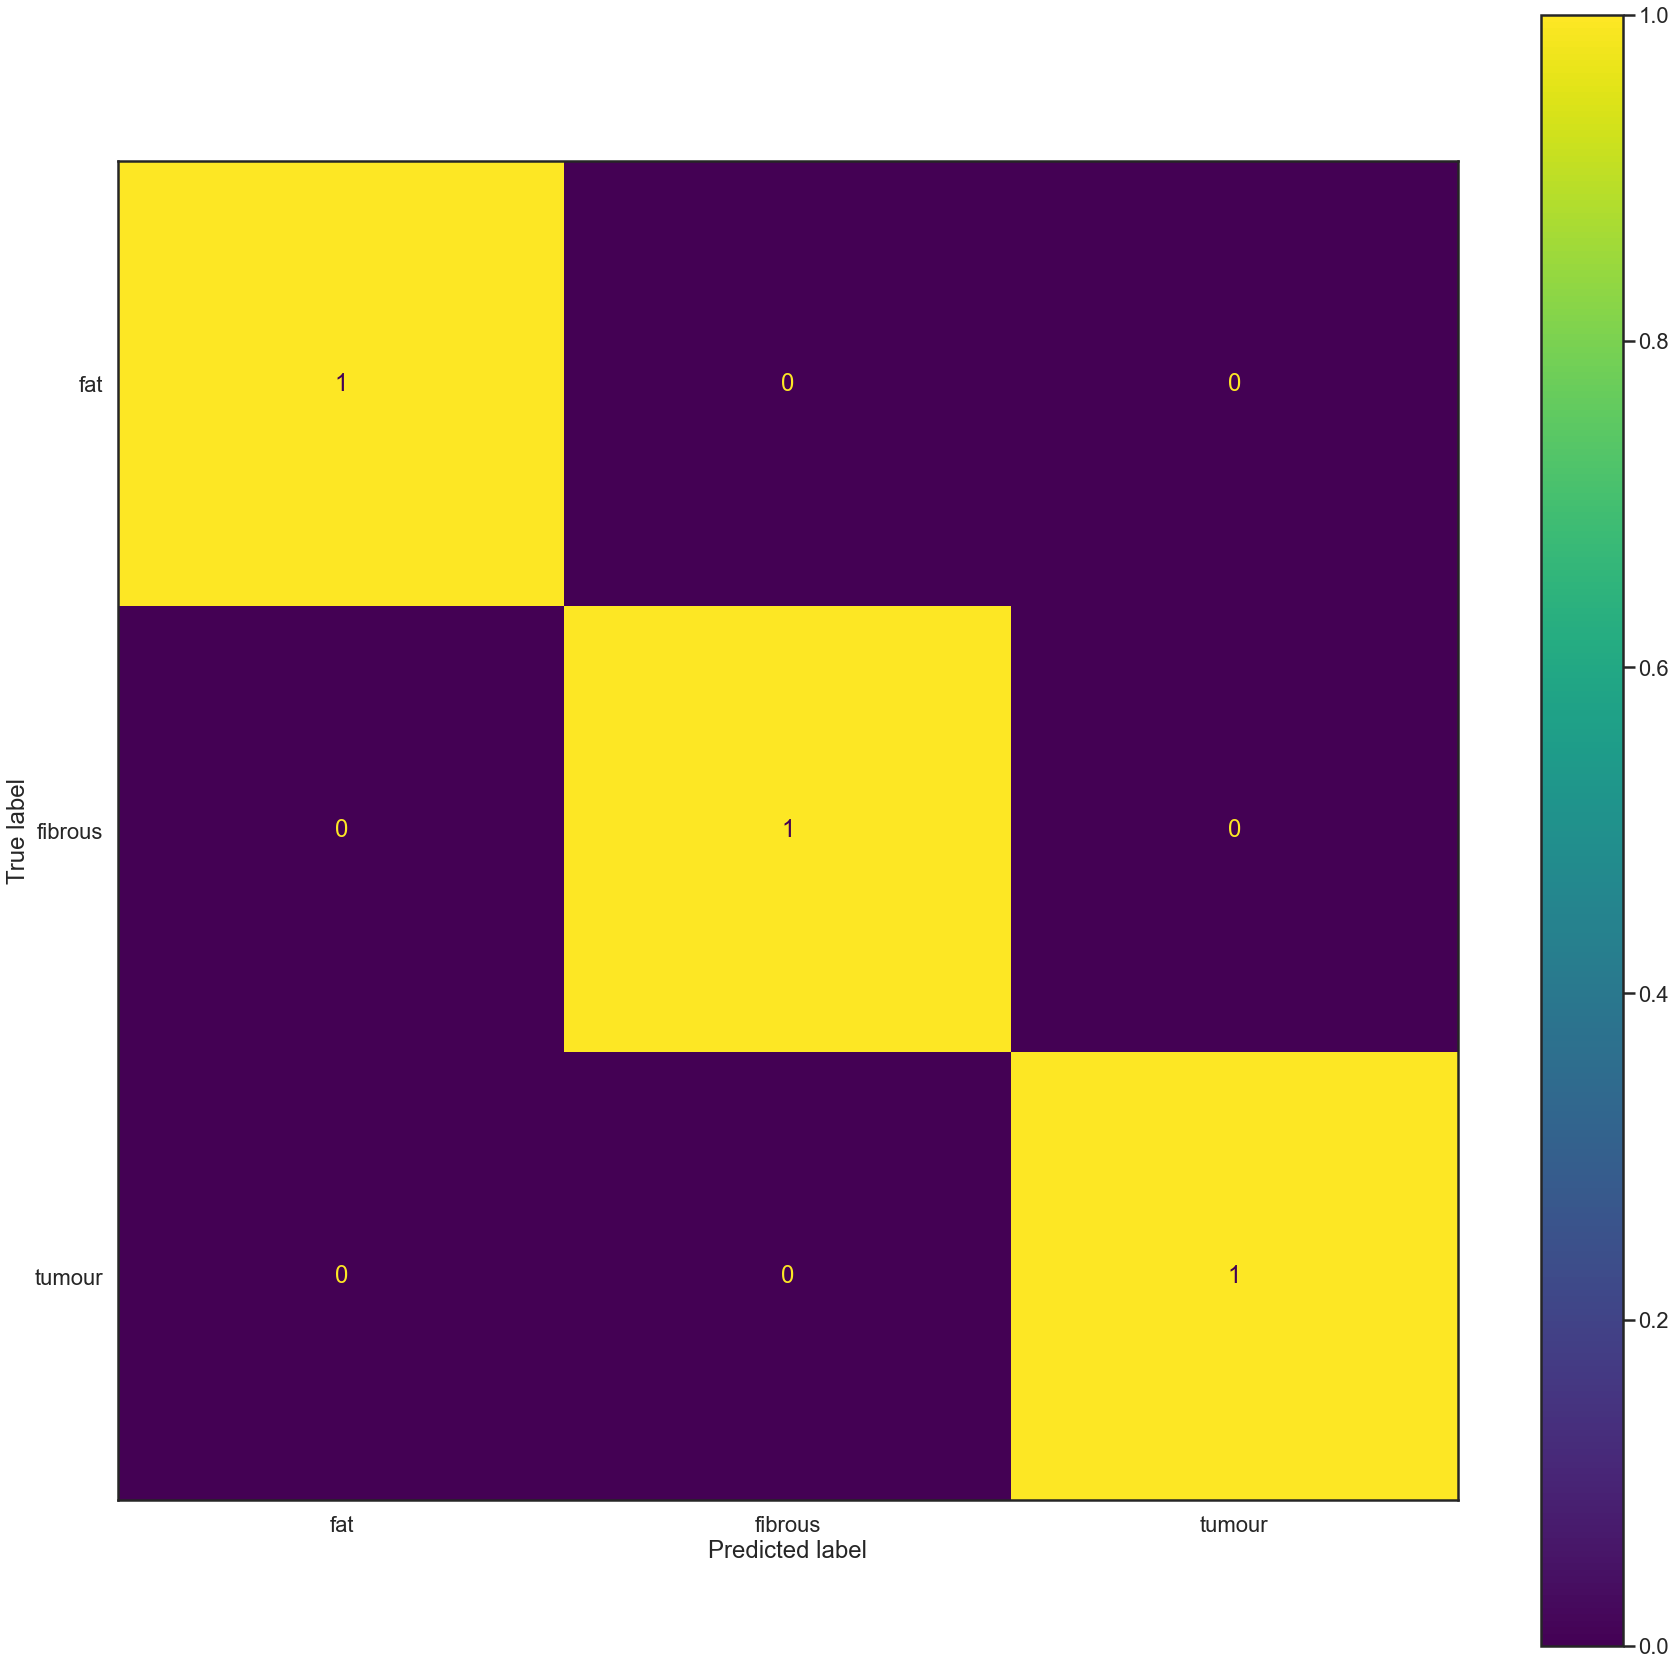

In [224]:
model_name = 'Trained_models/SVM_test.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Label'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

# Feature selection with univariate analysis

## Kruskal-Wallis test (non-parametric for multiple groups)

In [12]:
green = labelnames[1]
red = labelnames[0]
green_data=Data_train[tmp_train['colour']== green]
green_data = pd.DataFrame(green_data)
red_data=Data_train[tmp_train['colour']== red]
red_data = pd.DataFrame(red_data)
print('comparing '+ green+' & '+red)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

comparing red & green


## *Mann-Whitney test (non-parametric binary problem)

## KW test = MW test for a two-way comparison~

In [13]:
p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

## FDR correction

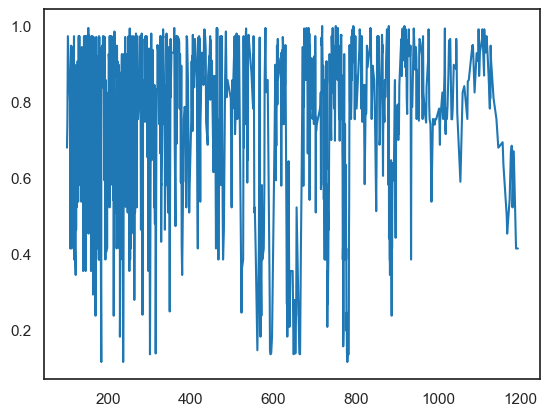

In [14]:
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)
correct_p=np.where(correct_p==0, 1e-15, correct_p) 
plt.plot(mz,correct_p)
# p_vals.shape

## *features can be selected based on corrected p-values alone or using volcano plot (below)

In [67]:
p_threshold = 0.05
features = [correct_p <= p_threshold]
features_KW = mz[tuple(features)]
features_KW

array([  61.0007515 ,   69.17650604,   85.27057648, ..., 1498.84692383,
       1499.19555664, 1500.20202637])

## fold changes calculation for volcano plot

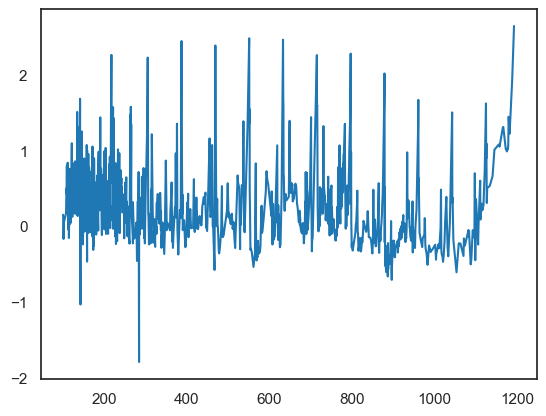

In [15]:
green_mean=np.mean(Data_train[tmp_train['colour']== green],0)
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(Data_train[tmp_train['colour']== red],0)
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)

plt.plot(mz,log2fc)

## plot and save volcano plot
## working example: https://www.reneshbedre.com/blog/volcano.html

In [19]:
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])

# volcano_data = pd.read_csv('E:/HyReS/results/DS brains/volcano_data_hyres.csv')
volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['m.z','p.value','t.score'])
volcano_data.iloc[:,1]=correct_p
volcano_data['p.value'] = volcano_data['p.value'].astype(float)
volcano_data.iloc[:,2]=log2fc
volcano_data.iloc[:,0]=mzlabel
top30=volcano_data['p.value'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)

sns.set_context("poster")
sns.set_style("white")

# visuz.GeneExpression.volcano(df=volcano_data, lfc='fc', pv='pvals', plotlegend=True, legendpos='upper right', 
#     legendanchor=(1.46,1))
fig = visuz.GeneExpression.volcano(df=volcano_data, lfc='t.score', pv='p.value',geneid='m.z', dim = [16,12],
                                   lfc_thr=(0.01, 0.01), pv_thr=(0.1, 0.1),
#                              genenames=({
# '134.1882935':'Adenine',
# '144.1821289':'Glutamine',
# '145.1835022':'Glutamate',
# '744.8551025':'PE(38:2)',
# '893.7605591':'TG(52:2)',
# }),
color=("purple", "grey", "#FFCC00"), dotsize = 10, gstyle = 2, gfont = 20.0, plotlegend=True,legendpos='upper left',
                                   axtickfontsize = 30, axlabelfontsize=30, sign_line=True,show=True)

AssertionError: either significant or non-significant genes are missing; try to change lfc_thr or pv_thr to include both significant and non-significant genes

## save volcano data for mummichog

In [20]:
volcano_data.to_csv (r'E:/IMAGING/FIM/volcano_data.csv', index = False, header=True)

## select features according volcano plot thresholds

In [38]:
p_threshold = 0.05
fc_threshold = 0.5
condition=(volcano_data['p.value'] <= p_threshold) & (abs(volcano_data['t.score']) >= fc_threshold)
vol_features=pd.DataFrame(mz[condition])

vol_features
# vol_features.to_csv (r'vol_features.csv', index = False, header=True)

,0
0,136.019526
1,189.053636
2,195.061848
3,217.022184
4,247.072022
5,252.002054
6,260.055823
7,273.055309
8,279.098202
9,287.059055


# Box plotting

## save box plots of selected features to defined path
## syntax: box_plot(list of features, mz, filename, column name to use for labels, save (True or False), savepath)

In [35]:
# features_from_file = np.loadtxt('features_OPO.txt')
features_from_file = pd.read_csv('E:/IMAGING/LD_REIMS/Monica/results/715_CALvsNAWM.csv')
# features_from_file = features_from_file.iloc[:,0]
features_from_file

,CAL,NAWM
0,0.000000,0.000000
1,248.235294,385.945926
2,0.000000,0.000000
3,0.000000,0.000000
4,28.960784,0.000000
...,...,...
6395,0.000000,591.670406
6396,488.196078,0.000000
6397,422.000000,351.941879
6398,515.777778,260.130954


In [36]:
import scipy
stat, pvalue = scipy.stats.ttest_ind(features_from_file['CAL'], features_from_file['NAWM'])
pvalue=np.reshape(pvalue,(1))
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(pvalue, alpha=0.05, method='indep', is_sorted=False)
print(stat)
print(correct_p)

-19.874738635934577
[1.35492363e-86]


<Axes: >

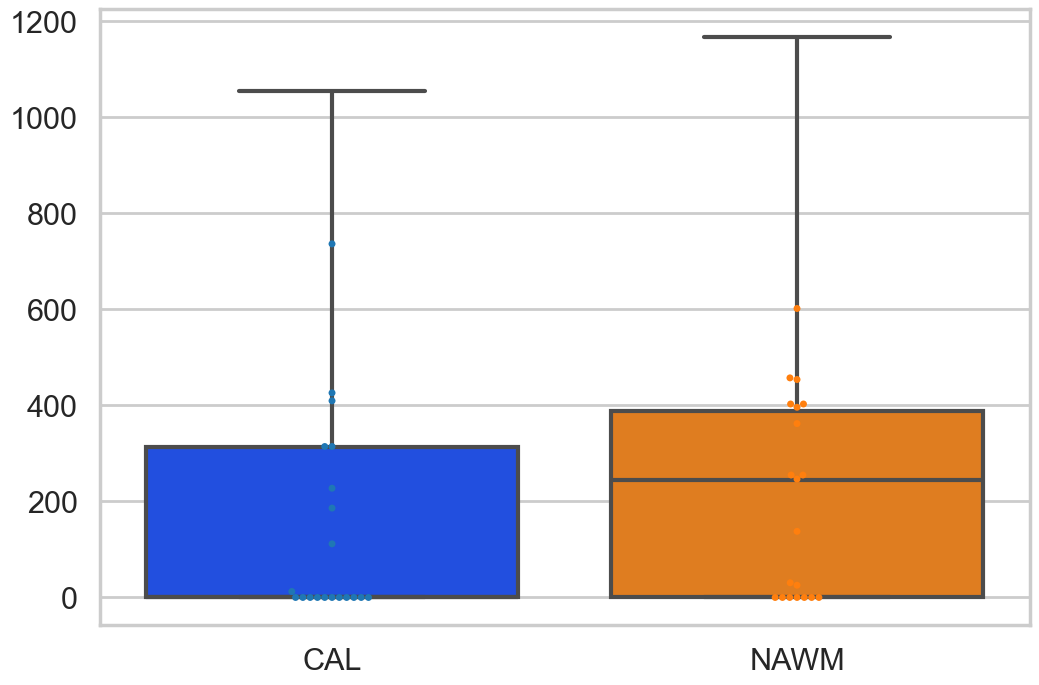

In [37]:
sns.set_style("whitegrid")
sns.set_context("poster")
fig = plt.figure(figsize=(12,8))
sns_plot = sns.boxplot(data=features_from_file, whis=5, palette = 'bright')
sns.swarmplot(data=features_from_file.sample(n=20, random_state=1))
# sns_plot = sns.violinplot(data=features_from_file, whis=5, palette = 'bright', scale = 'count', bw=1 )
# sns_plot.figure.savefig('D:/BOX/Box Sync/Publications/HyReS/figures/box_section2.3.png',dpi=600)
# plt.ylim([0,1200])

data too large! plotting using randomised 30% data points.


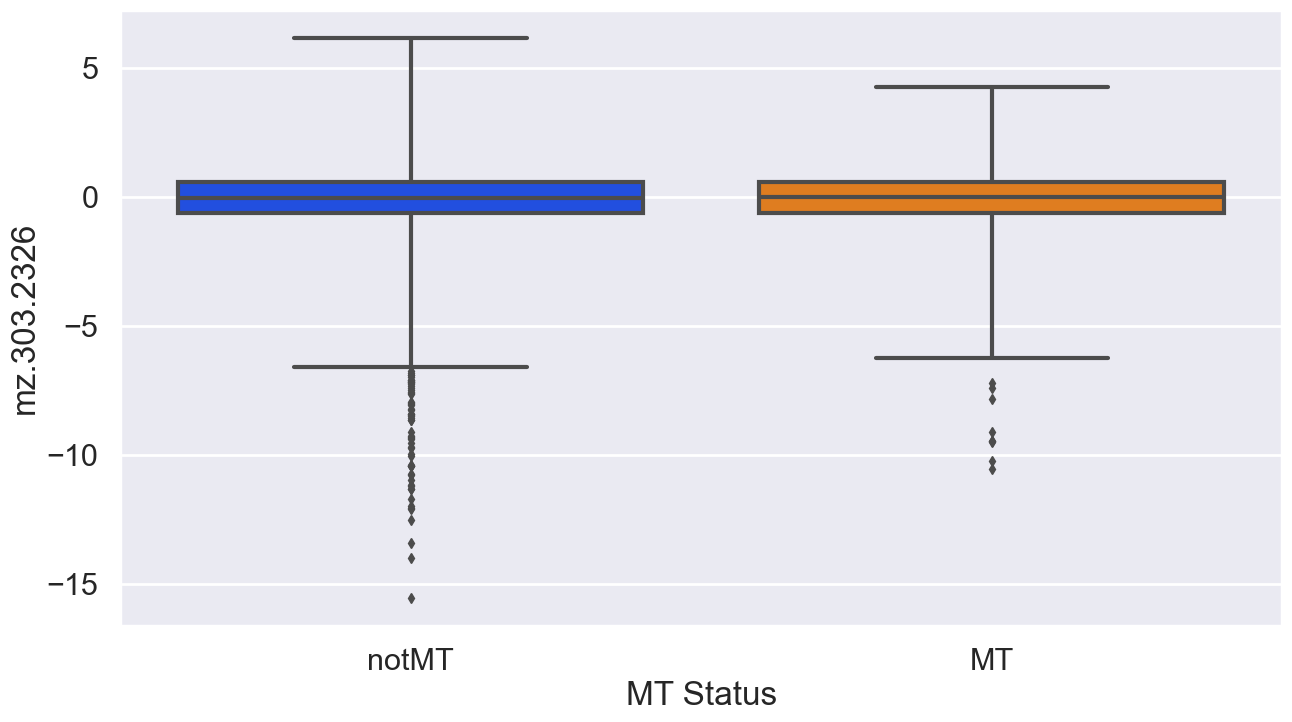

In [74]:
# box_plot(features_from_file, mz, tmp_train,'Class', save=True, savepath = 'E:/SPEC/hypoxia/')
box_plot(['mz.303.2326'], mz, tmp_train_r,'MT Status', save=False, savepath = 'D:/BOX/Box Sync/Publications/HyReS/figures',lcdata = True)

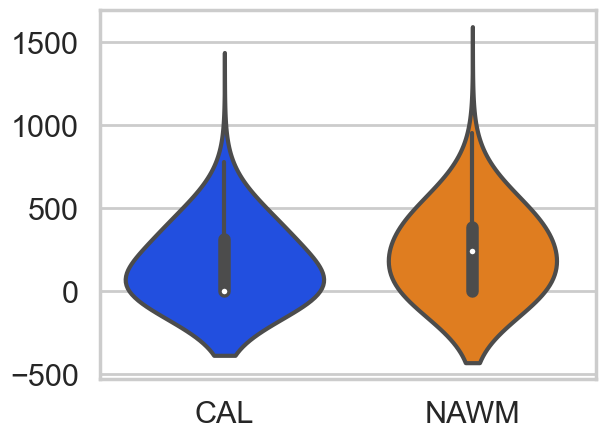

In [38]:
# ax = sns.violinplot(data=tmp_train_r,x="MT Status", y="mz.303.2326", whis=5, palette = 'bright', scale = 'count', bw=1, 
#                    density_norm='count',bw_method = 'silverman')
ax = sns.violinplot(data=features_from_file,whis=5, palette = 'bright', scale = 'area', bw=1, 
                   density_norm='count',bw_method = 'silverman')
# ax.set(ylim=(-5, 10))
# sns.swarmplot(data=tmp_train_r.sample(n=100, random_state=1))

In [64]:
# mz[189]
green_data=Data_train_r[tmp_train_r['MT Status']== 'notMT']
green_data = pd.DataFrame(green_data)
red_data=Data_train_r[tmp_train_r['MT Status']== 'MT']
red_data = pd.DataFrame(red_data)
pval = stats.kruskal(green_data.iloc[:,189],red_data.iloc[:,189])
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(pval, alpha=0.05, method='indep', is_sorted=False)
fc = np.mean(red_data.iloc[:,189])/np.mean(green_data.iloc[:,189])
print('pval: '+str(correct_p[1]))
print('fc: '+str(fc))

pval: 1.6660300556358089e-06
fc: 1.424996595785356


In [87]:
AA_cluster=pd.DataFrame(index=range(0,len(Data_train_r)),columns = ['Intensity','MT Status'])
AA_cluster.iloc[:,0]=tmp_train_r['mz.303.2326']
AA_cluster.iloc[:,1]=tmp_train_r['MT Status']

AA_cluster.to_csv (r'E:/CRUK/ICR/Paolo_Upload_Apr2024/Data/AA_cluster8.csv', index = False, header=True)